# Quantities of interest

The fixation probability of newly arising mutations

The expected heterozygosity of the population at a given point in time

The relative allelic contribution to the short-term phenotypic change after a shift per unit mutational input (which equals the allelic contribution to the phenotypic variance per unit mutational input)

The proportion of fixations due to adaptation, $\alpha$, in the McDonald-Kreitman test, with and without allele frequency cutoff

In [1]:
from plot_functions import *
%matplotlib inline

/insomnia001/home/jc5473/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/insomnia001/home/jc5473/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# common parameter values
fontsize = 8
N = 2000
U = 0.025
parallel_AA = 49
num_new_mutations = 10000000

In [3]:
E2Ns = 1
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

analytic_V_A = np.zeros((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        # each individual analytic V_A is obtained by iteratively applying V_A_shifts() onto the value from the previous iteration until convergence; the initial value is the analytic V_A under no shifts
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A[index_shift_s0][index_rate_of_shift] = pickle.load(f)

E2Ns = 16
shift_s0_partitioning_nonLande = 29
rate_of_shifts_partitioning_nonLande = 66

analytic_V_A_nonLande = np.zeros((shift_s0_partitioning_nonLande, rate_of_shifts_partitioning_nonLande))
for index_shift_s0 in range(shift_s0_partitioning_nonLande):
    for index_rate_of_shift in range(rate_of_shifts_partitioning_nonLande):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift] = pickle.load(f)

/insomnia001/home/jc5473/my_code/plot_functions.py:160: RuntimeWarning: overflow encountered in exp
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/insomnia001/home/jc5473/my_code/plot_functions.py:160: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/insomnia001/home/jc5473/my_code/plot_functions.py:362: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, shift_s0, sigma_0_del), 0.0, np.inf)[0] + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, -shift_s0, sigma_0_del), 0.0, np.inf)[0]) / V_Delta_x_drift_and_shifts(a, z, np.sqrt(2), 

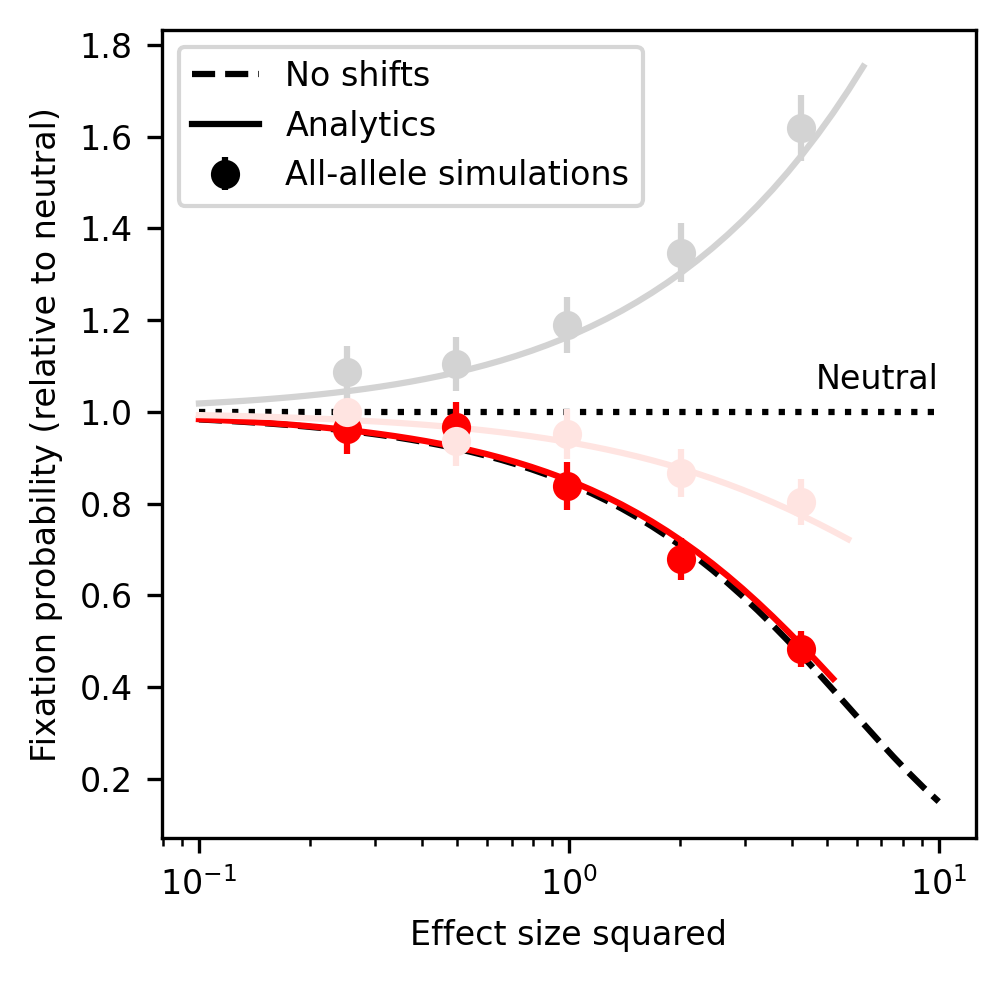

In [6]:
# # the fixation probability under recurrent shifts, where the size of each shift independently follows a (Gamma) distribution (the graph shows the three qualitatively different behaviors), in the Lande case
# E2Ns = 1
# nE = 100
# indices_ss = [21, 38, 62, 86, 98]

# V2Ns = E2Ns ** 2
# S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
#                                                scale=float(V2Ns) / float(E2Ns))
# a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
# a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

# fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
# ax = fig.add_subplot(1, 1, 1)

# shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
# rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
# shift_s0_partitioning = 32
# rate_of_shifts_partitioning = 57

# neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

# no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

# index_shift_s0, shift_s0 = 15, 1.5
# index_rate_of_shift, rate_of_shift = 9, 0.00075

# fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
# ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='r')

# index_rate_of_shift, rate_of_shift = 28, 0.012

# fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
# ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='mistyrose')

# index_rate_of_shift, rate_of_shift = 37, 0.048

# fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
# ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='lightgray')

# ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

# simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
# analytics, = ax.plot([], [], 'k-')

# ax.set_xscale('log')
# ax.set_xlabel('Effect size squared', fontsize=fontsize)
# ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# plt.xticks(fontsize=fontsize)
# plt.yticks(fontsize=fontsize)
# plt.show()

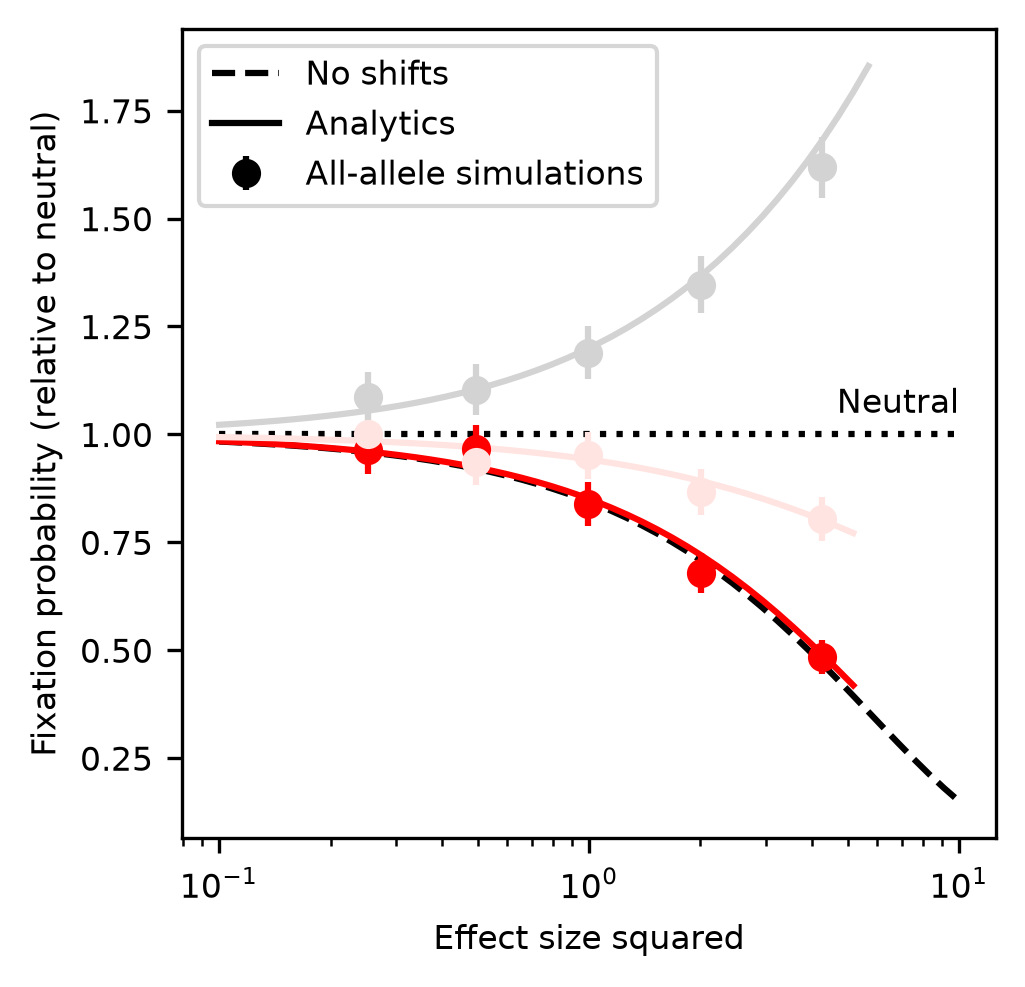

In [6]:
# the fixation probability under recurrent shifts, where the size of each shift independently follows a (Gamma) distribution (the graph shows the three qualitatively different behaviors), in the Lande case
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='r')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(0.1, 10), pickle.load(f), color='r')

index_rate_of_shift, rate_of_shift = 28, 0.012

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='mistyrose')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(0.1, 10), pickle.load(f), color='mistyrose')

index_rate_of_shift, rate_of_shift = 37, 0.048

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
# ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='lightgray')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(0.1, 10), pickle.load(f), color='lightgray')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_3082743/2012594366.py:34: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


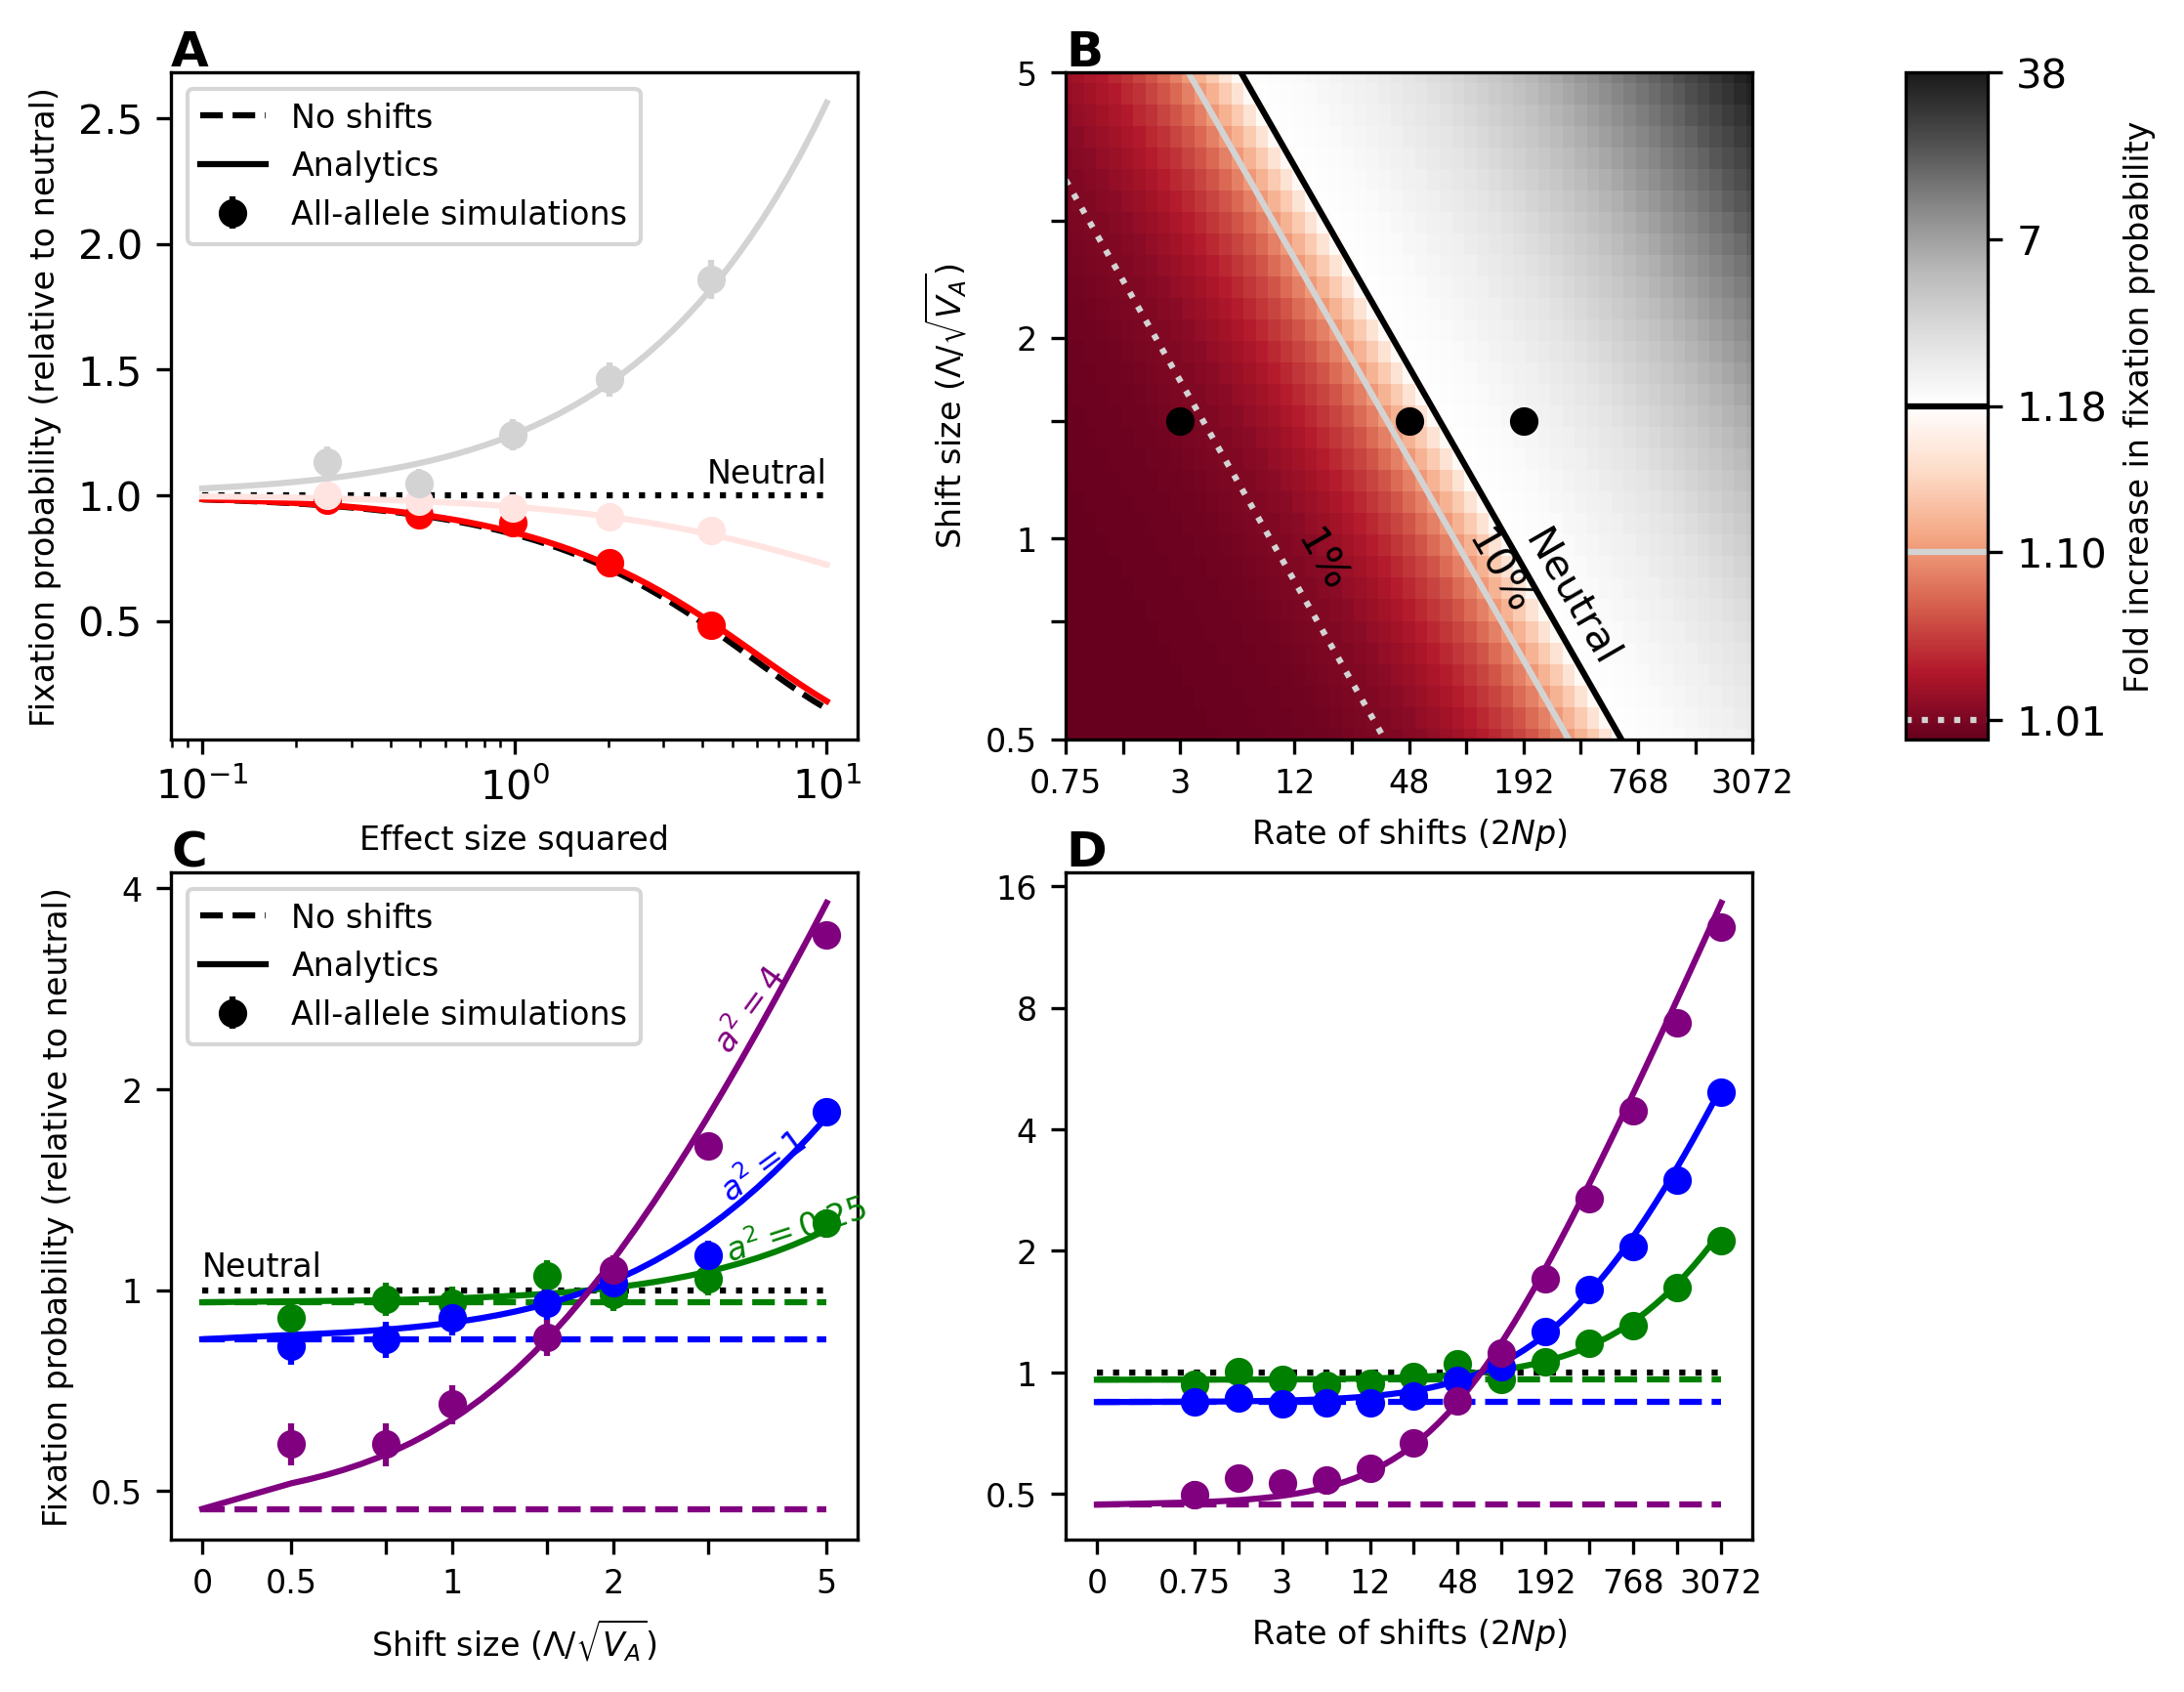

In [7]:
# the fixation probability under recurrent shifts, in the Lande case
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.01, 1.1, 1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % 1.1, '%.2f' % (1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
# panel A: the three qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='r')

index_rate_of_shift, rate_of_shift = 28, 0.012

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 37, 0.048

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='lightgray')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# panel B: the effect of recurrent shifts on the fixation probability
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot([analytic_V_A[np.searchsorted(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), 1)][np.searchsorted(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), V_A(E2Ns=1) / 1 ** 2 / (2 * N))] / shift_s0 ** 2 for shift_s0 in np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=12, y=1, s='1%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=96, y=1, s='10%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=192, y=1, s='Neutral', color='k', rotation=-60, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.00075, 0.012, 0.048]), [1.5, 1.5, 1.5], color='k')

# panels C and D: the fixation probability as a function of the shift size (or the rate of shifts) for a given rate of shifts (or the shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'g'], [indices_ss[2], 1, 'b'], [indices_ss[4], 4.25, 'purple']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.multiply(fixation_probability_mean_wrt_shift_s0, 2 * N), yerr=np.multiply(fixation_probability_se_wrt_shift_s0, 1.96 * 2 * N), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.05, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=1.1, s='$a^2=%g$' % 0.25, color='g', rotation=18, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=1.35, s='$a^2=%g$' % 1, color='b', rotation=36, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=2.25, s='$a^2=%g$' % 4, color='purple', rotation=54, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + [0.5, 0.75, 1, 1.5, 2, 3, 5], labels=[0] + [0.5, None, 1, None, 2, None, 5], fontsize=fontsize)
ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'g'], [indices_ss[2], 1, 'b'], [indices_ss[4], 4.25, 'purple']]):
    fixation_probability_mean_wrt_rate_of_shift, fixation_probability_se_wrt_rate_of_shift = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.multiply(fixation_probability_mean_wrt_rate_of_shift, 2 * N), yerr=np.multiply(fixation_probability_se_wrt_rate_of_shift, 1.96 * 2 * N), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + [0.75, 1.5, 3, 6, 12, 24, 48, 96, 192, 384, 768, 1536, 3072], labels=[0] + [0.75, None, 3, None, 12, None, 48, None, 192, None, 768, None, 3072], fontsize=fontsize)
ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

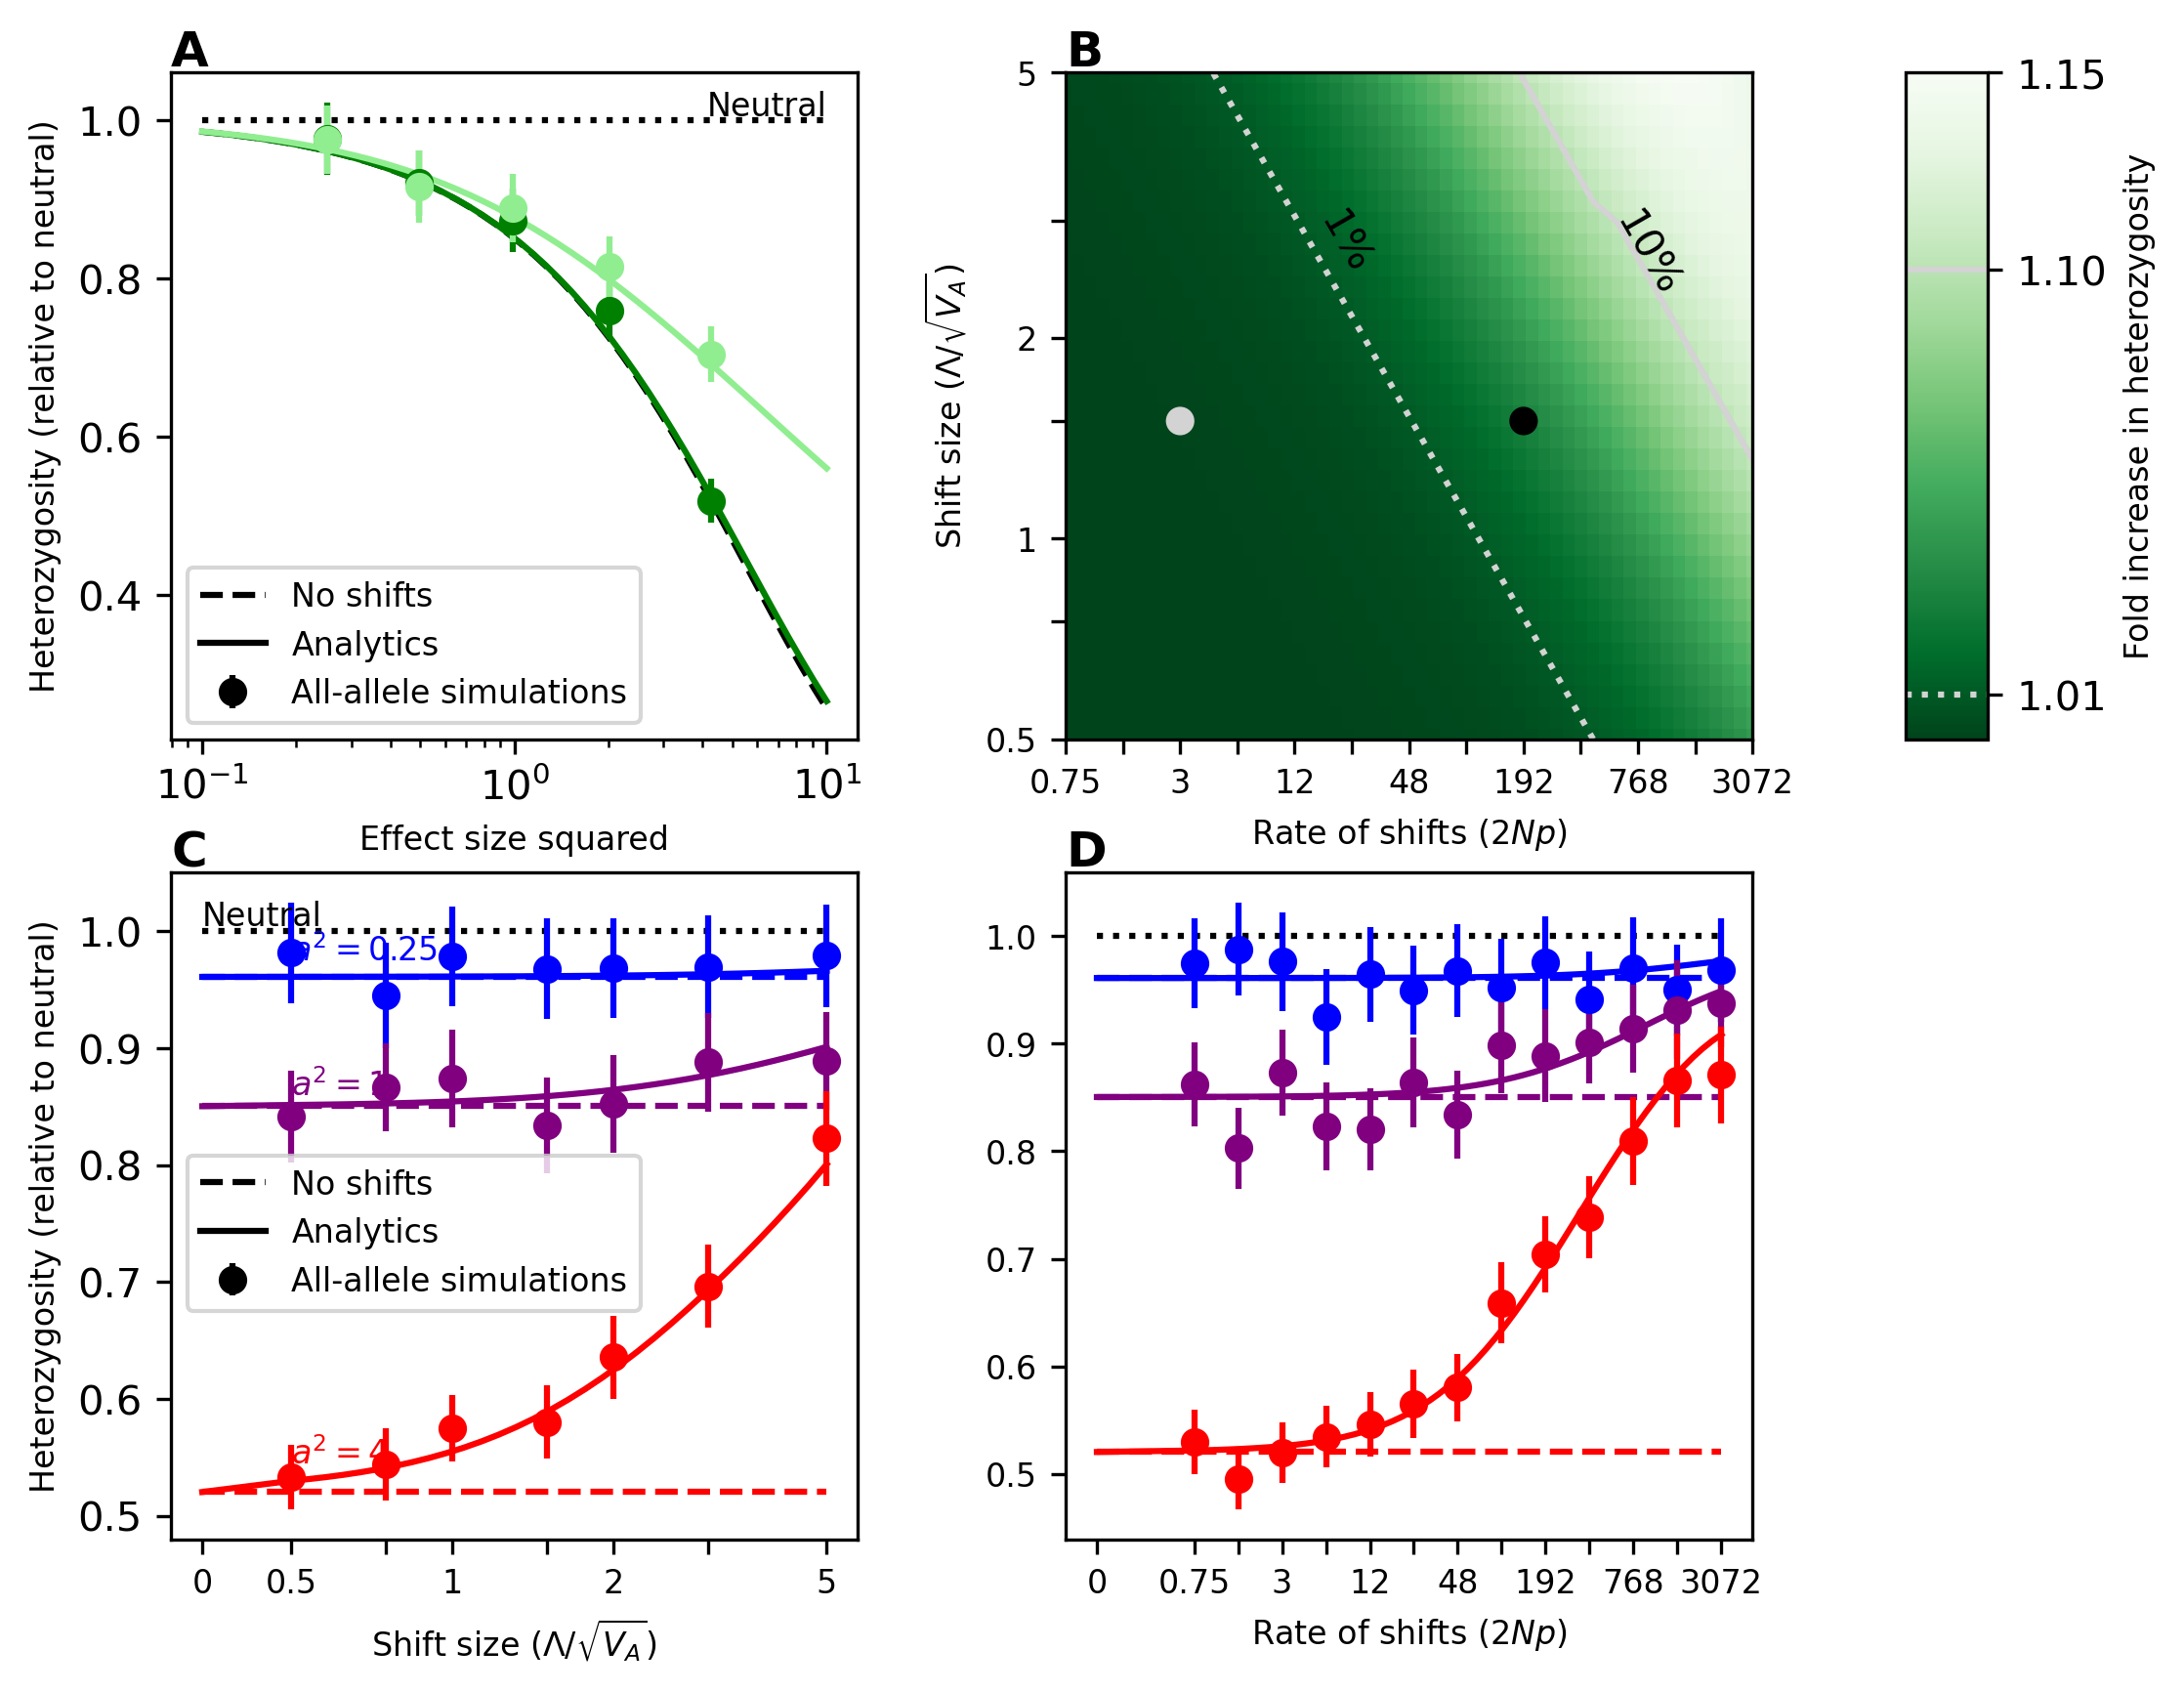

In [6]:
# the heterozygosity under recurrent shifts, in the Lande case
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

# the average heterozygosity over the effect size distribution
Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            Z[index_shift_s0, index_rate_of_shift] = pickle.load(f)
Z = np.divide(Z, heterozygosity_(a=np.sqrt(E2Ns)))
z_min, z_max = Z.min(), Z.max()

norm = colors.Normalize(vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='Greens_r', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in heterozygosity', fontsize=fontsize)
cbar.ax.set_yticks([1.01, 1.105, z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % 1.1, '%.2f' % z_max])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.105, color='lightgray', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
# panel A: the two qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color='g')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='g')

index_rate_of_shift, rate_of_shift = 37, 0.048

heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color='lightgreen')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='lightgreen')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the effect of recurrent shifts on the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

norm = colors.Normalize(vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='Greens_r', norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.105)] if Z[index_shift_s0, -1] >= 1.105 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle='-')
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.01)] if Z[index_shift_s0, -1] >= 1.01 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=16, y=3, s='1%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=576, y=3, s='10%', color='k', rotation=-60, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.00075, 0.048]), [1.5, 1.5], color=['lightgray', 'k'])

# panels C and D: the heterozygosity as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.975, s='$a^2=%g$' % 0.25, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.86, s='$a^2=%g$' % 1, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.545, s='$a^2=%g$' % 4, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.6), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

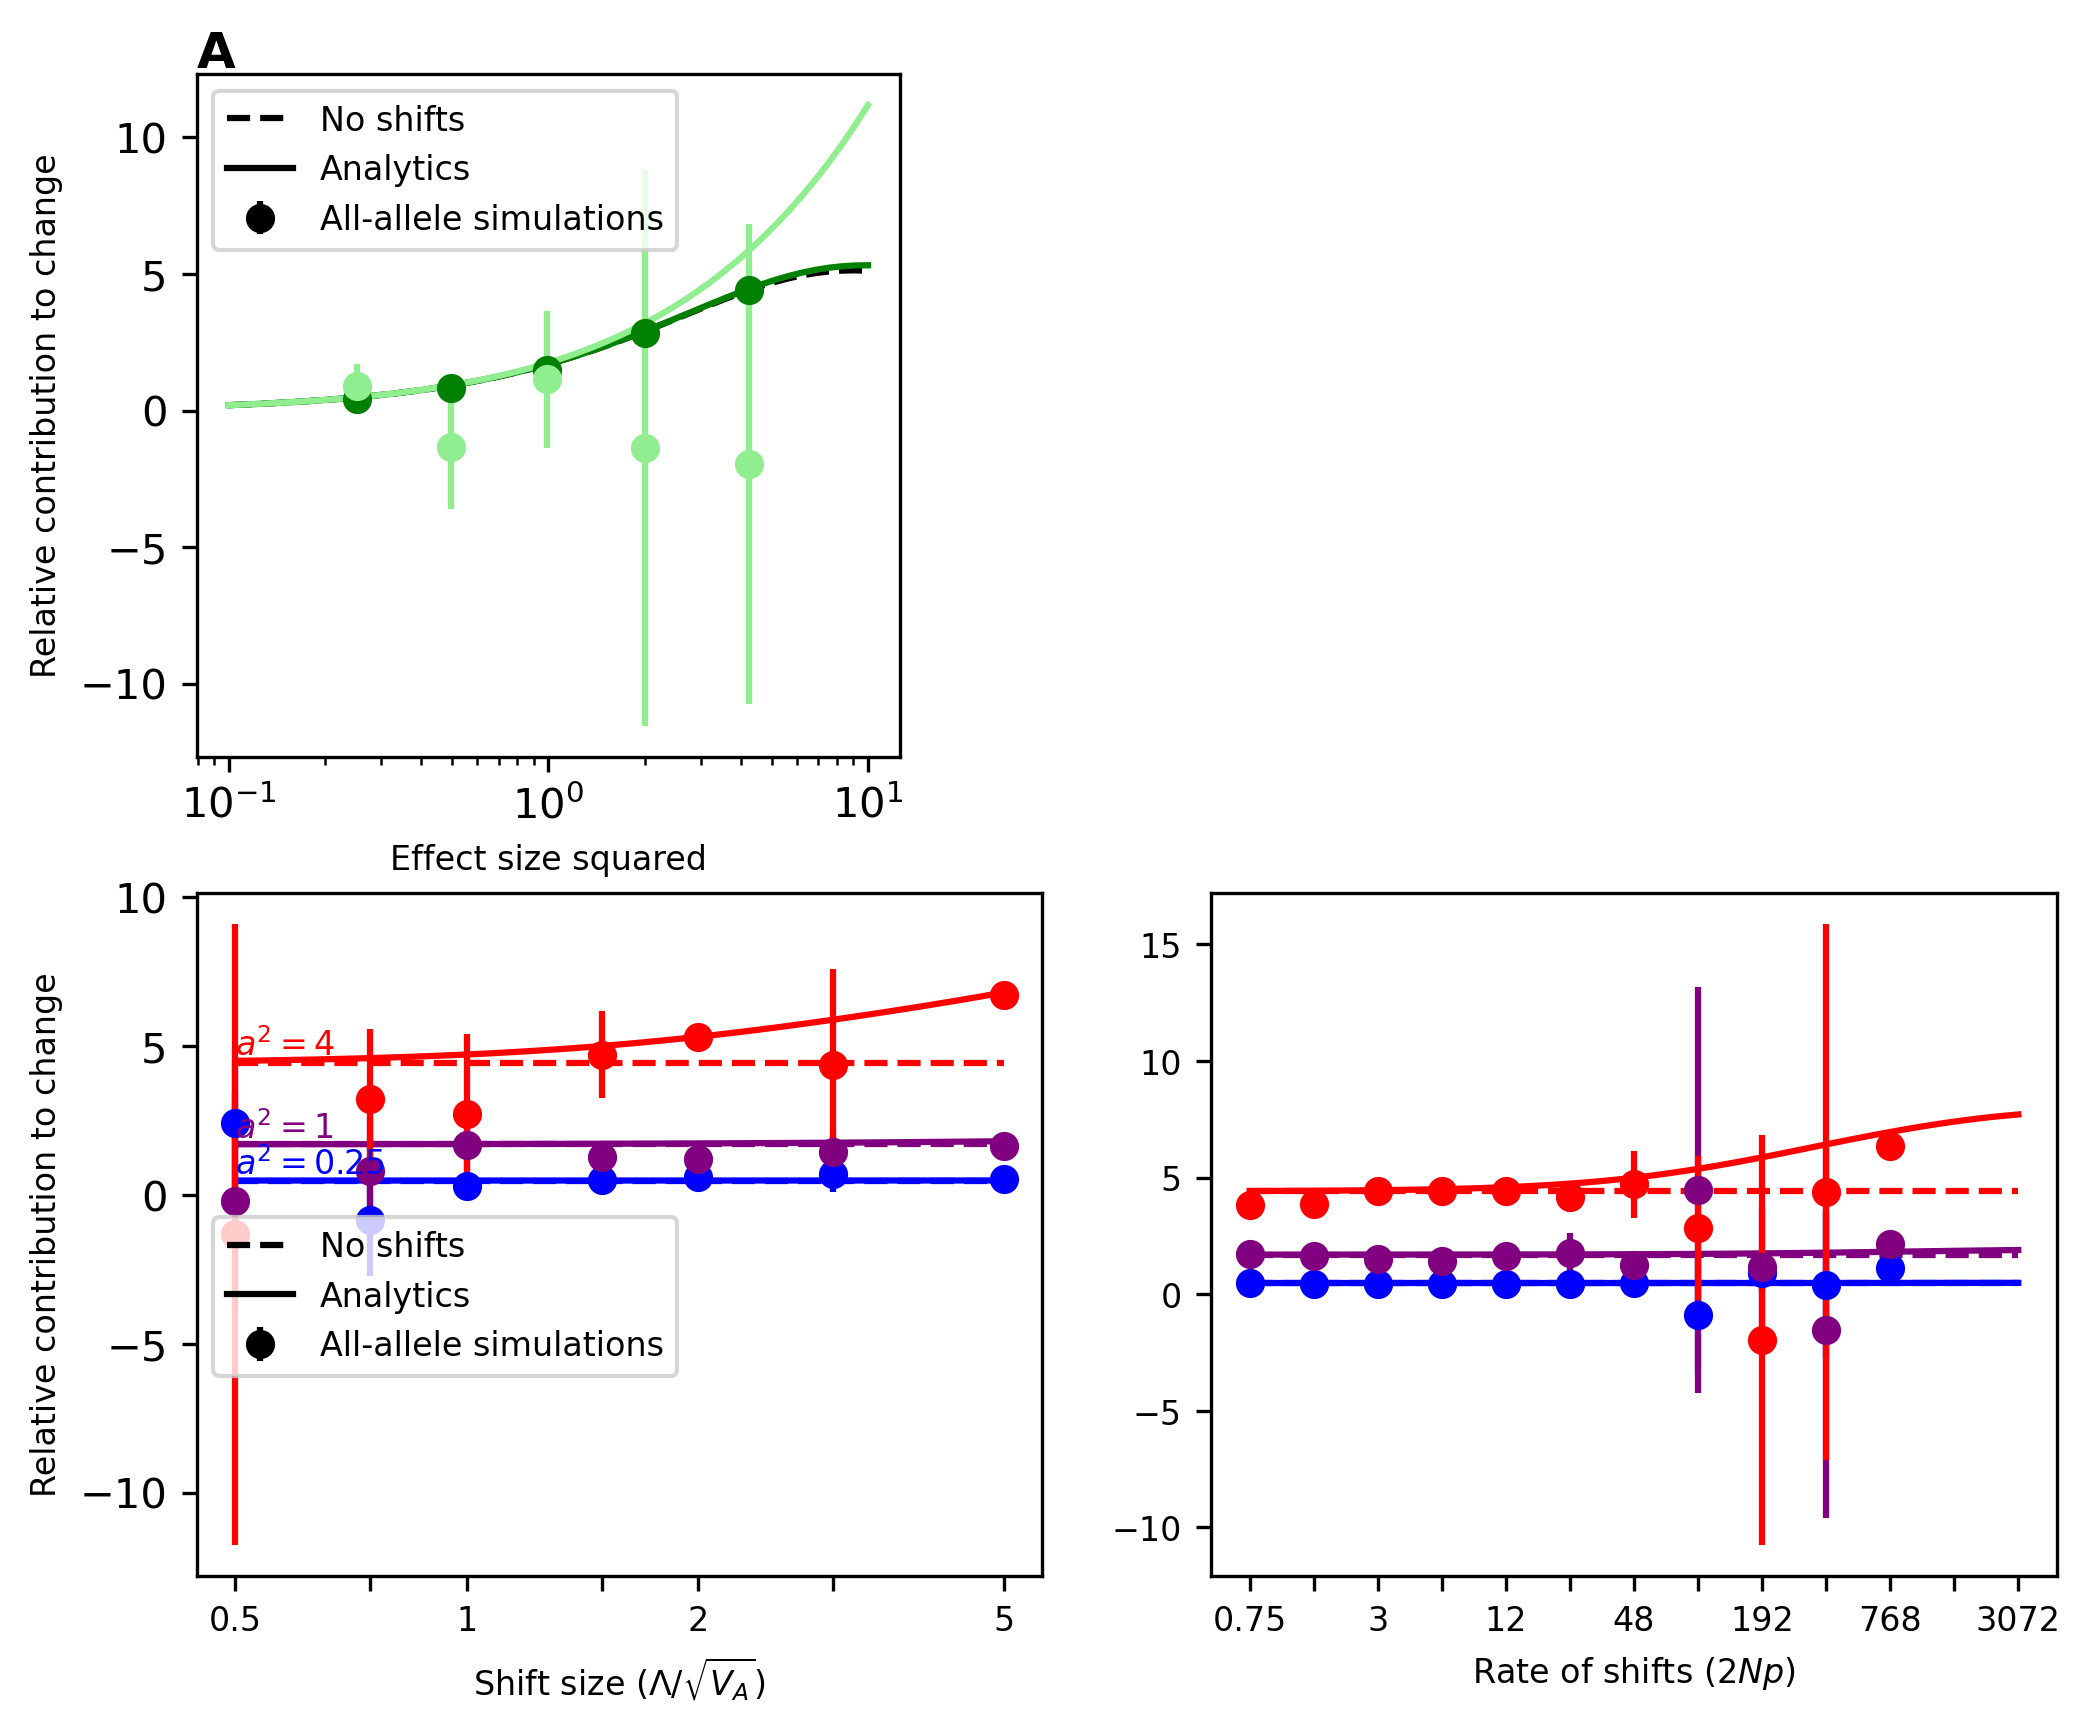

In [6]:
# the relative allelic contribution to the short-term phenotypic change after a shift, in the Lande case
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

# panel A: the two qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [v_(a=np.sqrt(ss)) for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

# contribution_to_change_mean, contribution_to_change_se = calculate_contribution_to_change_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, E2Ns=E2Ns, nE=nE)
with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_mean = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_se = pickle.load(f)

ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(contribution_to_change_mean, (2 * N * U / (nE + 1))), yerr=1.96 * np.divide(contribution_to_change_se, (2 * N * U / (nE + 1))), fmt='o', color='g')
ax.plot(np.geomspace(0.1, 10), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(0.1, 10)], color='g')

index_rate_of_shift, rate_of_shift = 37, 0.048

# contribution_to_change_mean, contribution_to_change_se = calculate_contribution_to_change_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, E2Ns=E2Ns, nE=nE)
with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_mean = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_se = pickle.load(f)

ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(contribution_to_change_mean, (2 * N * U / (nE + 1))), yerr=1.96 * np.divide(contribution_to_change_se, (2 * N * U / (nE + 1))), fmt='o', color='lightgreen')
ax.plot(np.geomspace(0.1, 10), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(0.1, 10)], color='lightgreen')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the relative allelic contribution to the short-term phenotypic change after a shift as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size), for a few effect sizes

ax = fig.add_subplot(2, 2, 3)

index_rate_of_shift, rate_of_shift = 28, 0.012

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    # contribution_to_change_mean_wrt_shift_s0, contribution_to_change_se_wrt_shift_s0 = calculate_contribution_to_change_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, E2Ns=E2Ns, nE=nE)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_wrt_shift_s0_N_%d_U_' % N + str(U).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_mean_wrt_shift_s0 = pickle.load(f)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_wrt_shift_s0_N_%d_U_' % N + str(U).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_se_wrt_shift_s0 = pickle.load(f)
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(contribution_to_change_mean_wrt_shift_s0, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_shift_s0, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [v_(a=np.sqrt(ss)) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=shift_s0_list[0], y=0.7, s='$a^2=%g$' % 0.25, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=1.9, s='$a^2=%g$' % 1, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=4.7, s='$a^2=%g$' % 4, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.55), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = fig.add_subplot(2, 2, 4)

index_shift_s0, shift_s0 = 15, 1.5

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    # contribution_to_change_mean_wrt_rate_of_shifts, contribution_to_change_se_wrt_rate_of_shifts = calculate_contribution_to_change_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, E2Ns=E2Ns, nE=nE)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_wrt_rate_of_shifts_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_mean_wrt_rate_of_shifts = pickle.load(f)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_wrt_rate_of_shifts_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_se_wrt_rate_of_shifts = pickle.load(f)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(contribution_to_change_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [v_(a=np.sqrt(ss)) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

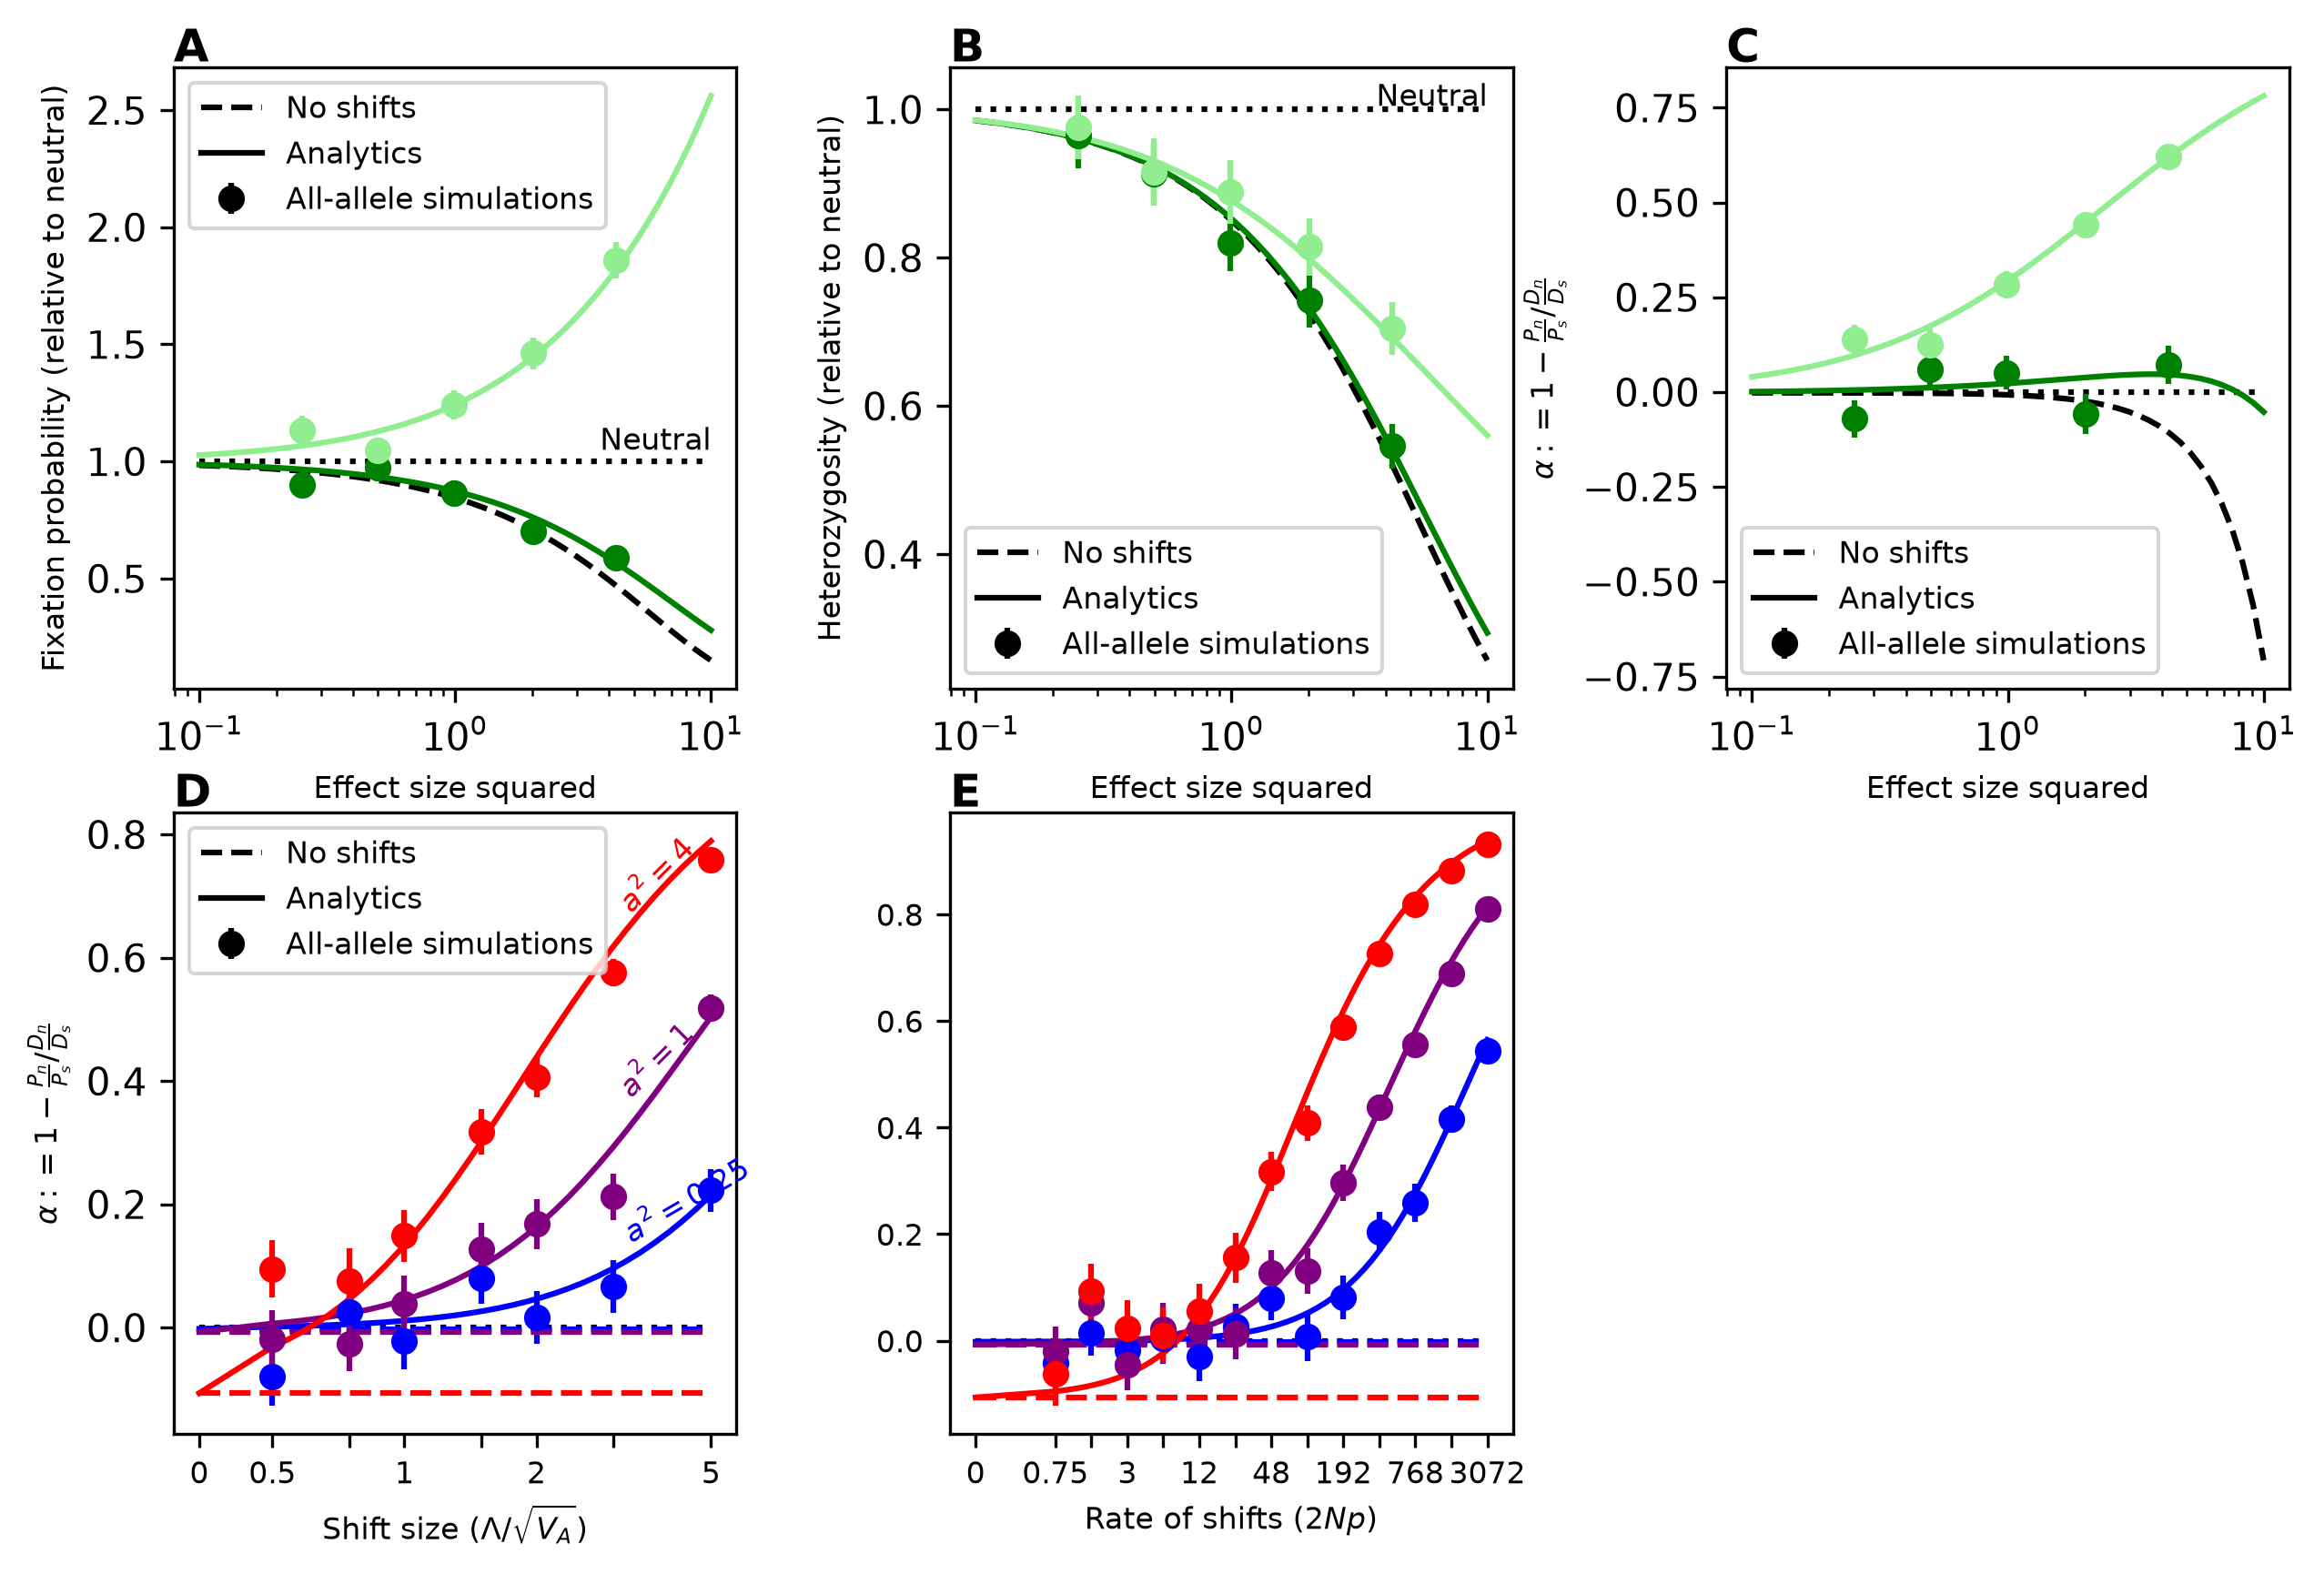

In [6]:
# McDonald-Kreitman test, in the Lande case
# without frequency cutoff
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    ## obtain the fixation probability of alleles with each a^2
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

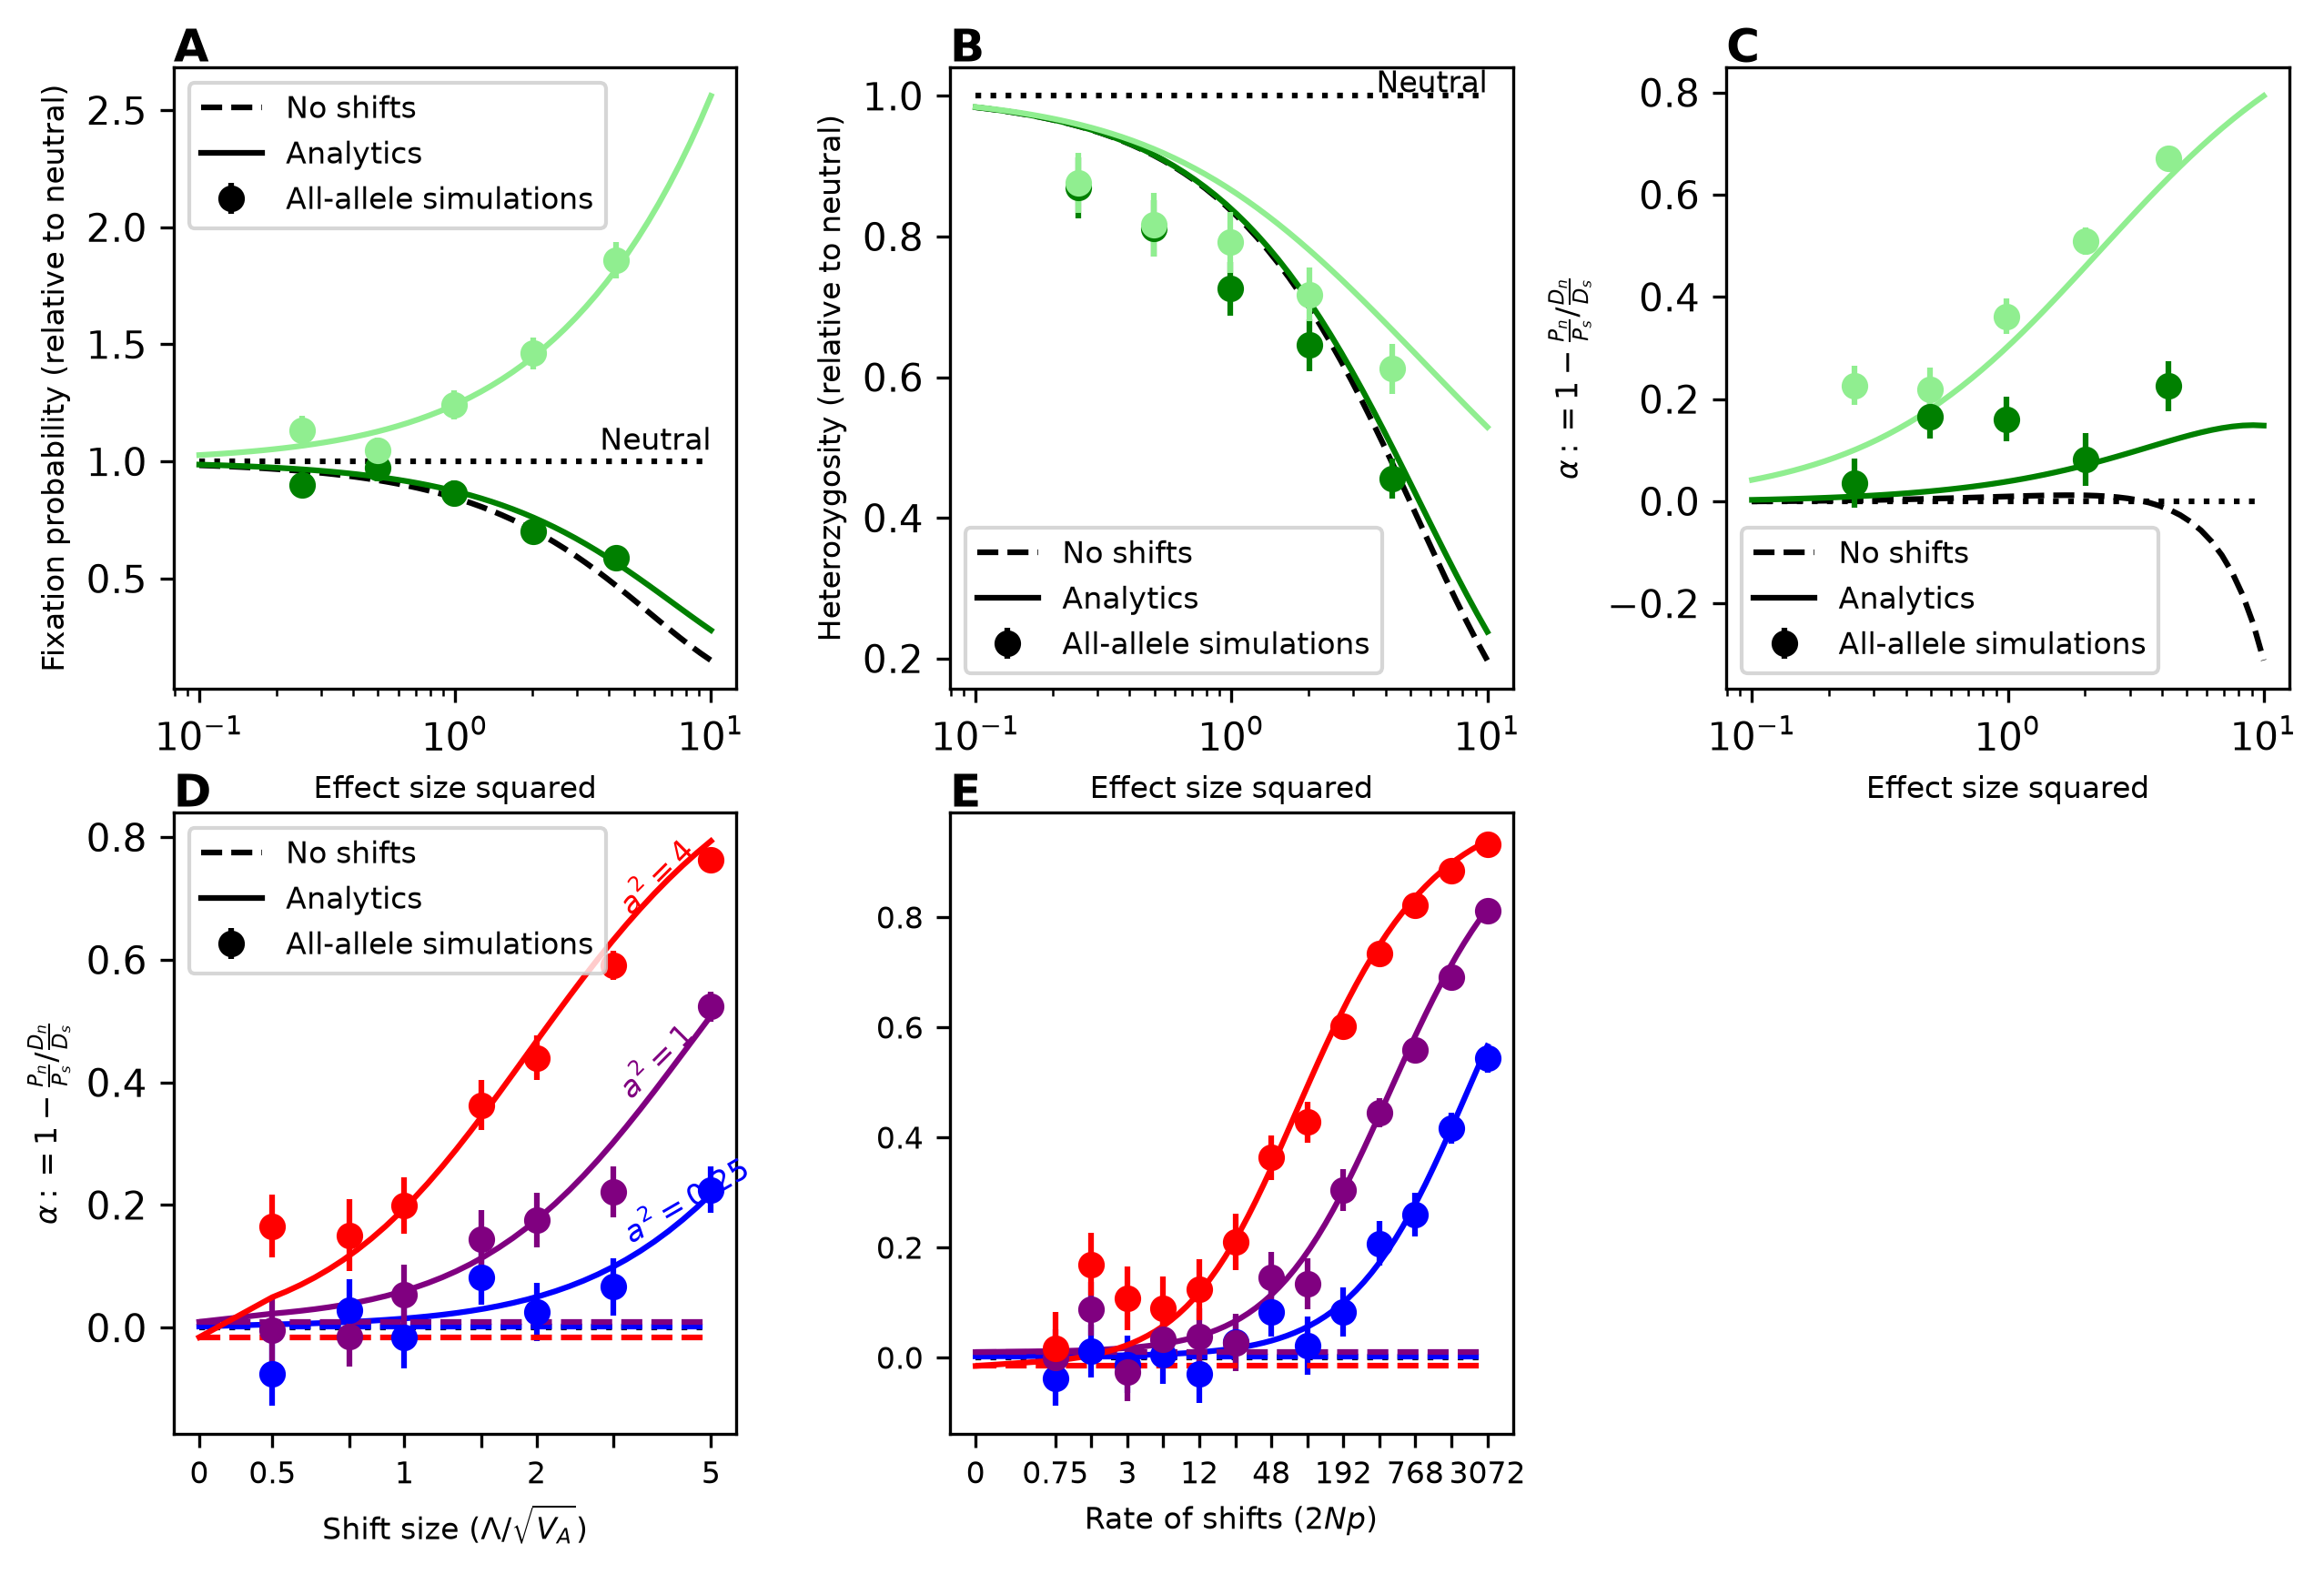

In [7]:
# McDonald-Kreitman test, in the Lande case
# with frequency cutoff 0.05
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

maf_threshold = 0.05

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE, maf_threshold=maf_threshold)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

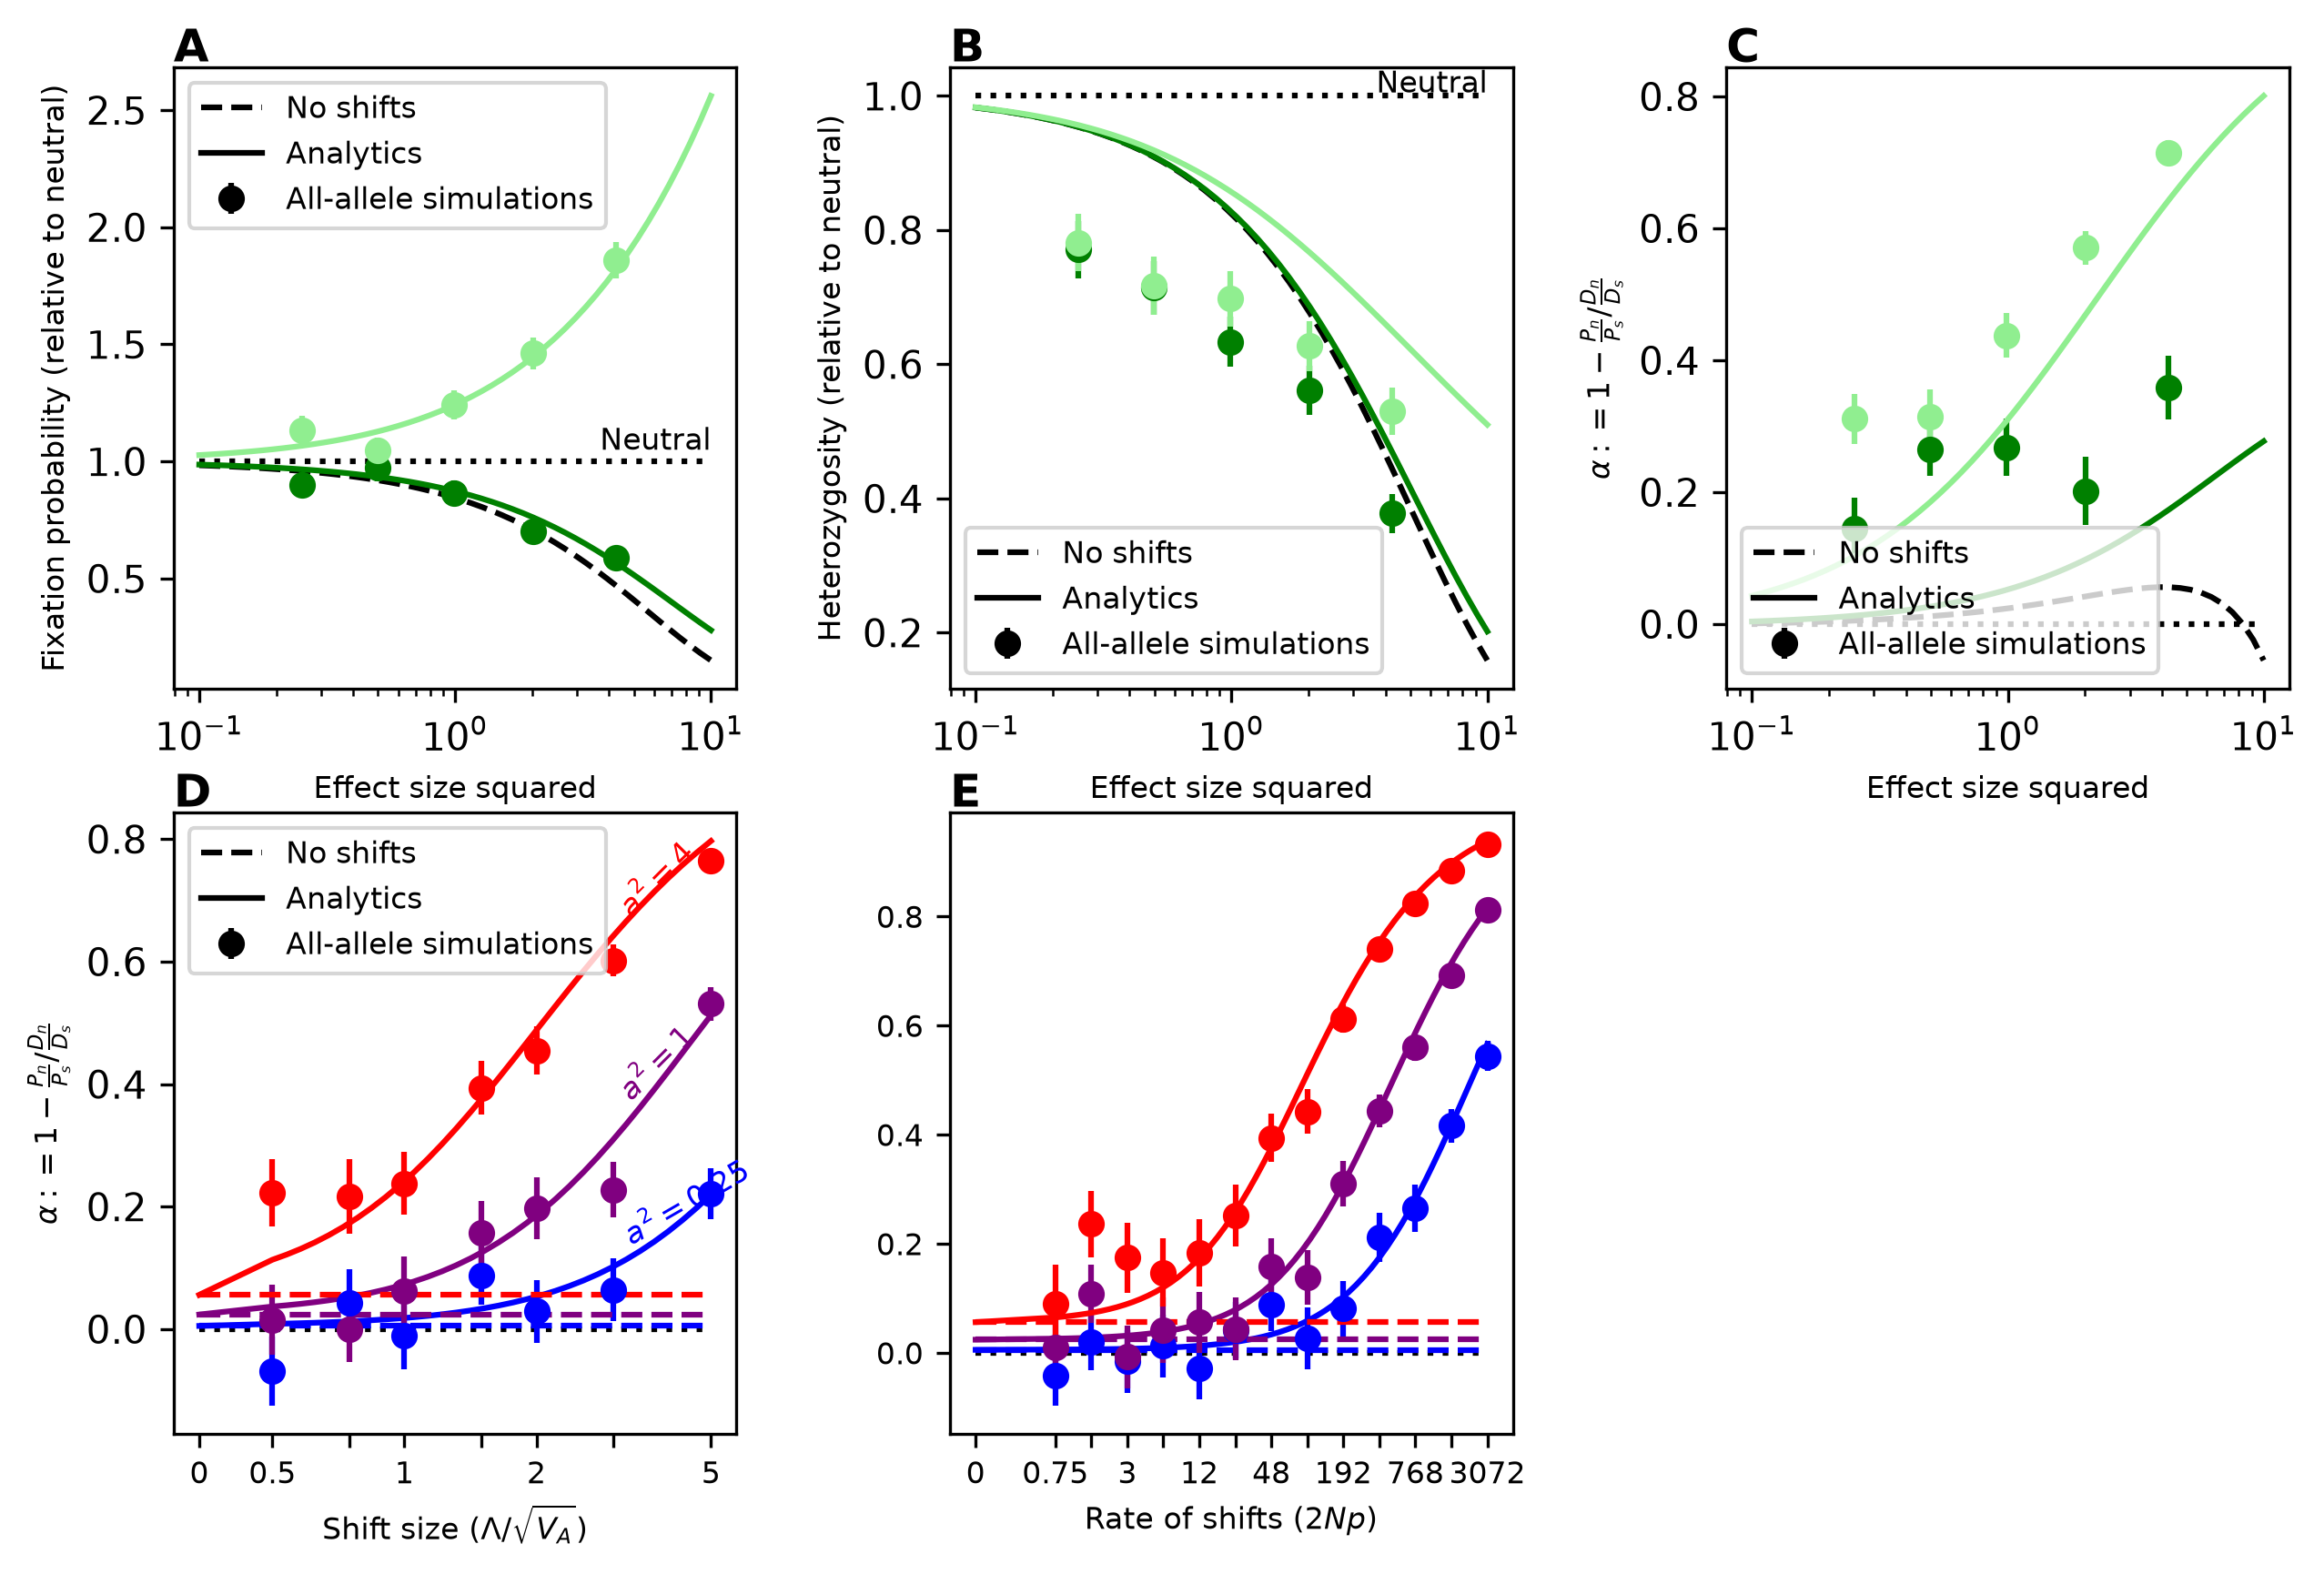

In [8]:
# McDonald-Kreitman test, in the Lande case
# with frequency cutoff 0.1
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

maf_threshold = 0.1

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE, maf_threshold=maf_threshold)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

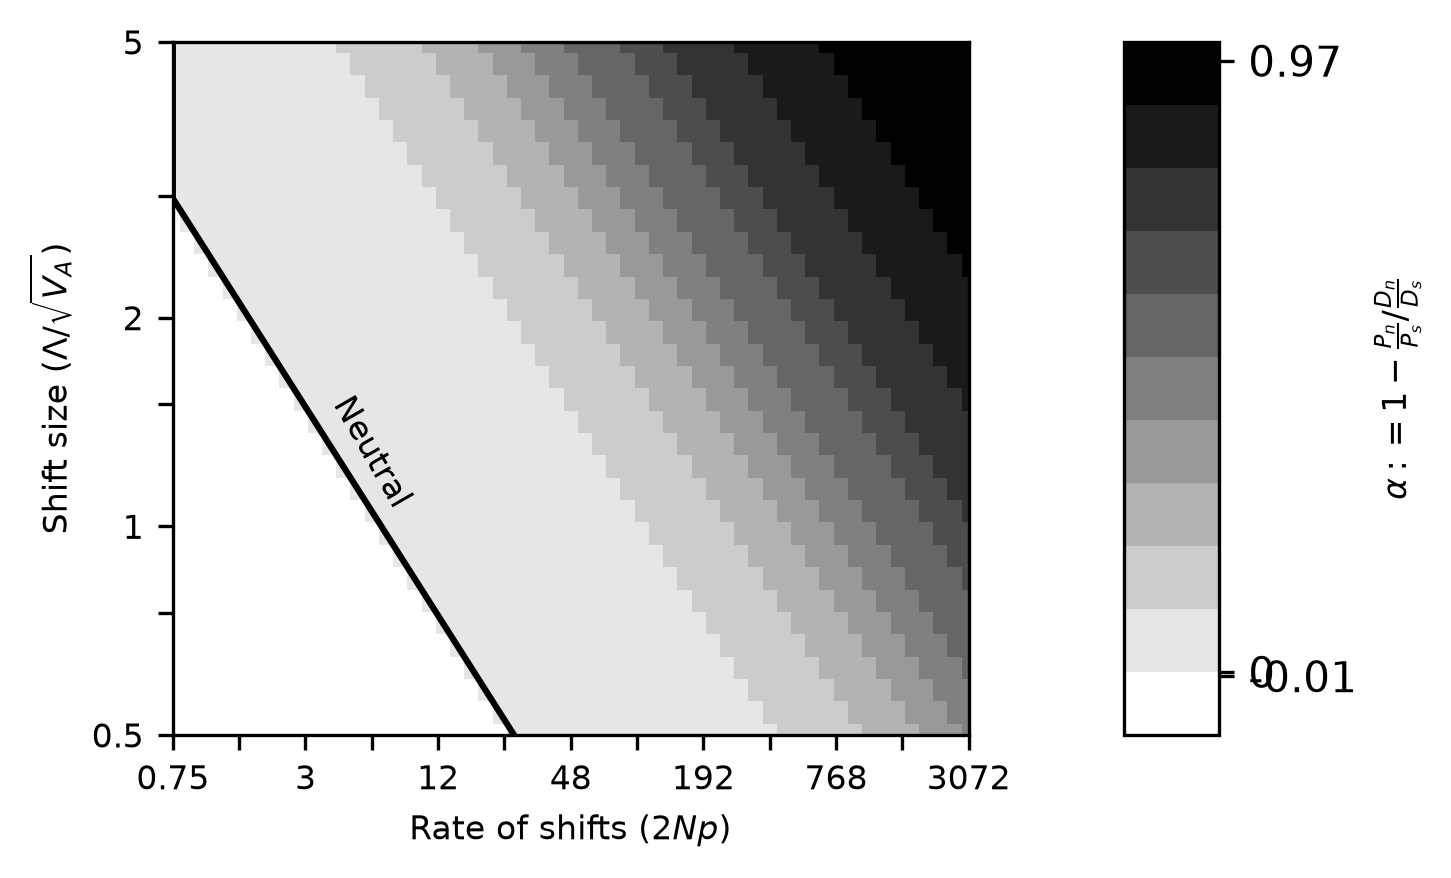

In [8]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['1', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-0.1, 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

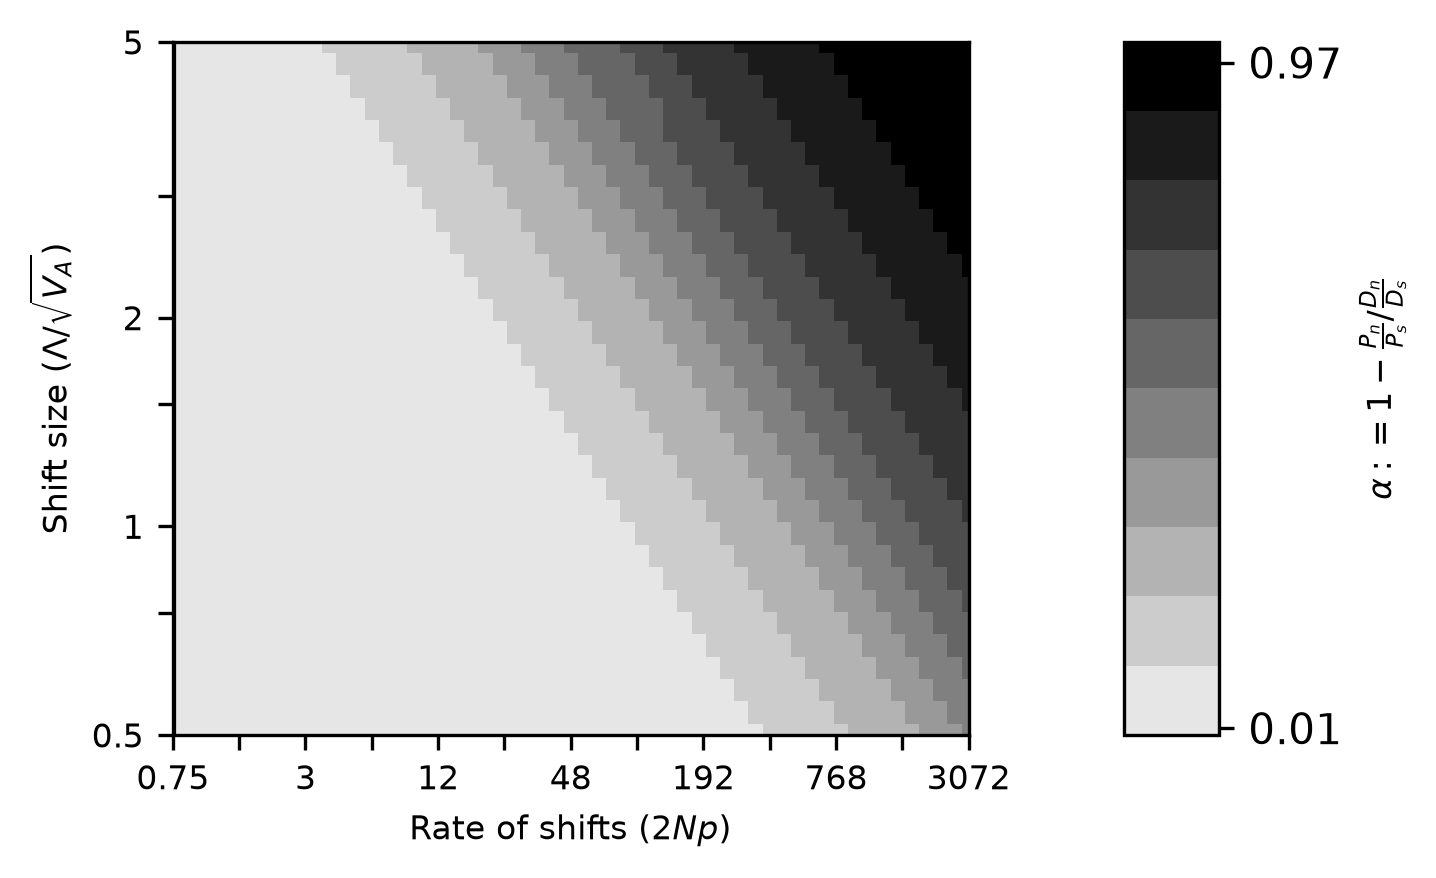

In [9]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

maf_threshold = 0.05

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(0., 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
# ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

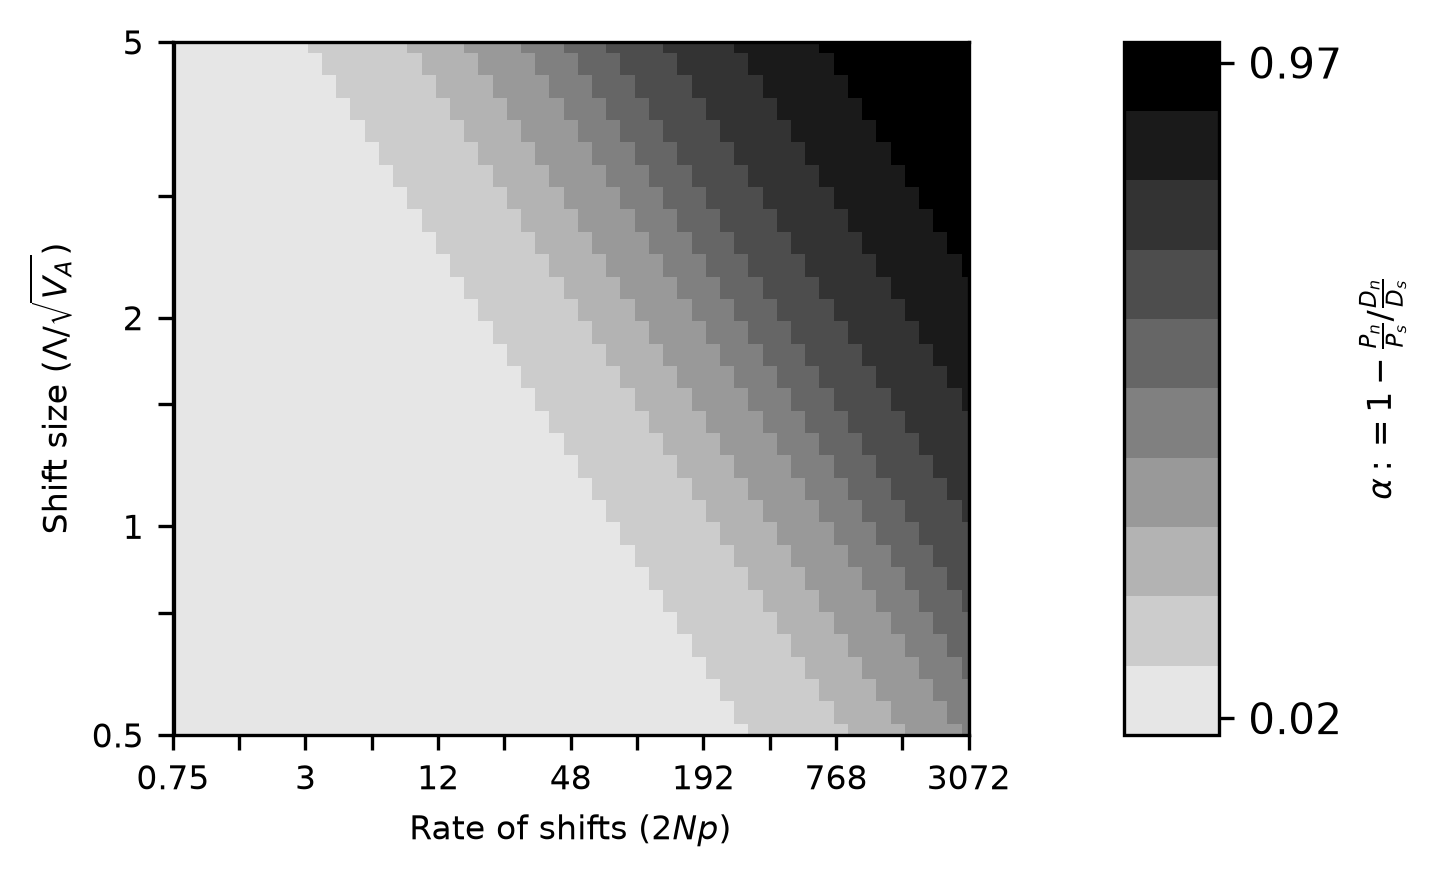

In [10]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

maf_threshold = 0.1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(0., 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
# ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

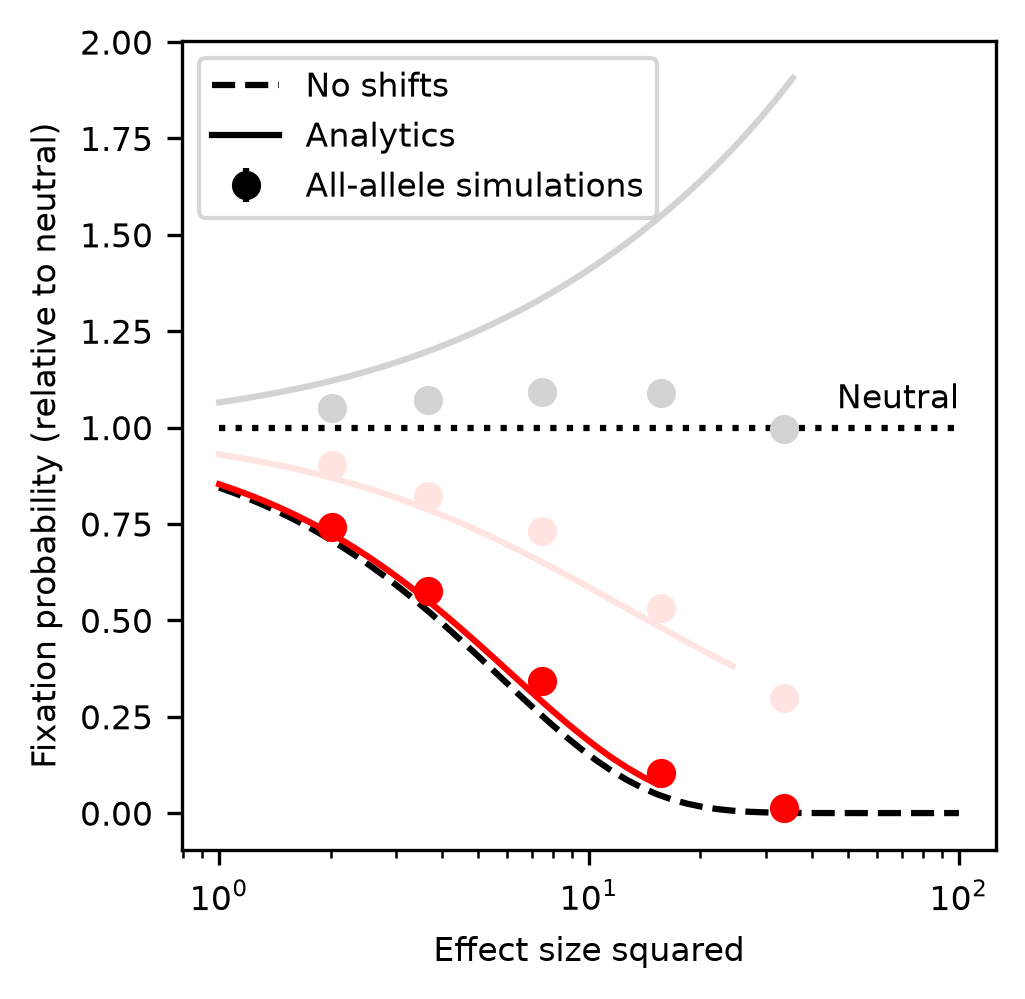

In [6]:
# the fixation probability under recurrent shifts, where the size of each shift independently follows a (Gamma) distribution (the graph shows the three qualitatively different behaviors), in the non-Lande case
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
# ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(1, 100), pickle.load(f), color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
# ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(1, 100), pickle.load(f), color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
# ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')
with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_fixation_probability_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    ax.plot(np.geomspace(1, 100), pickle.load(f), color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_2235034/958633448.py:34: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


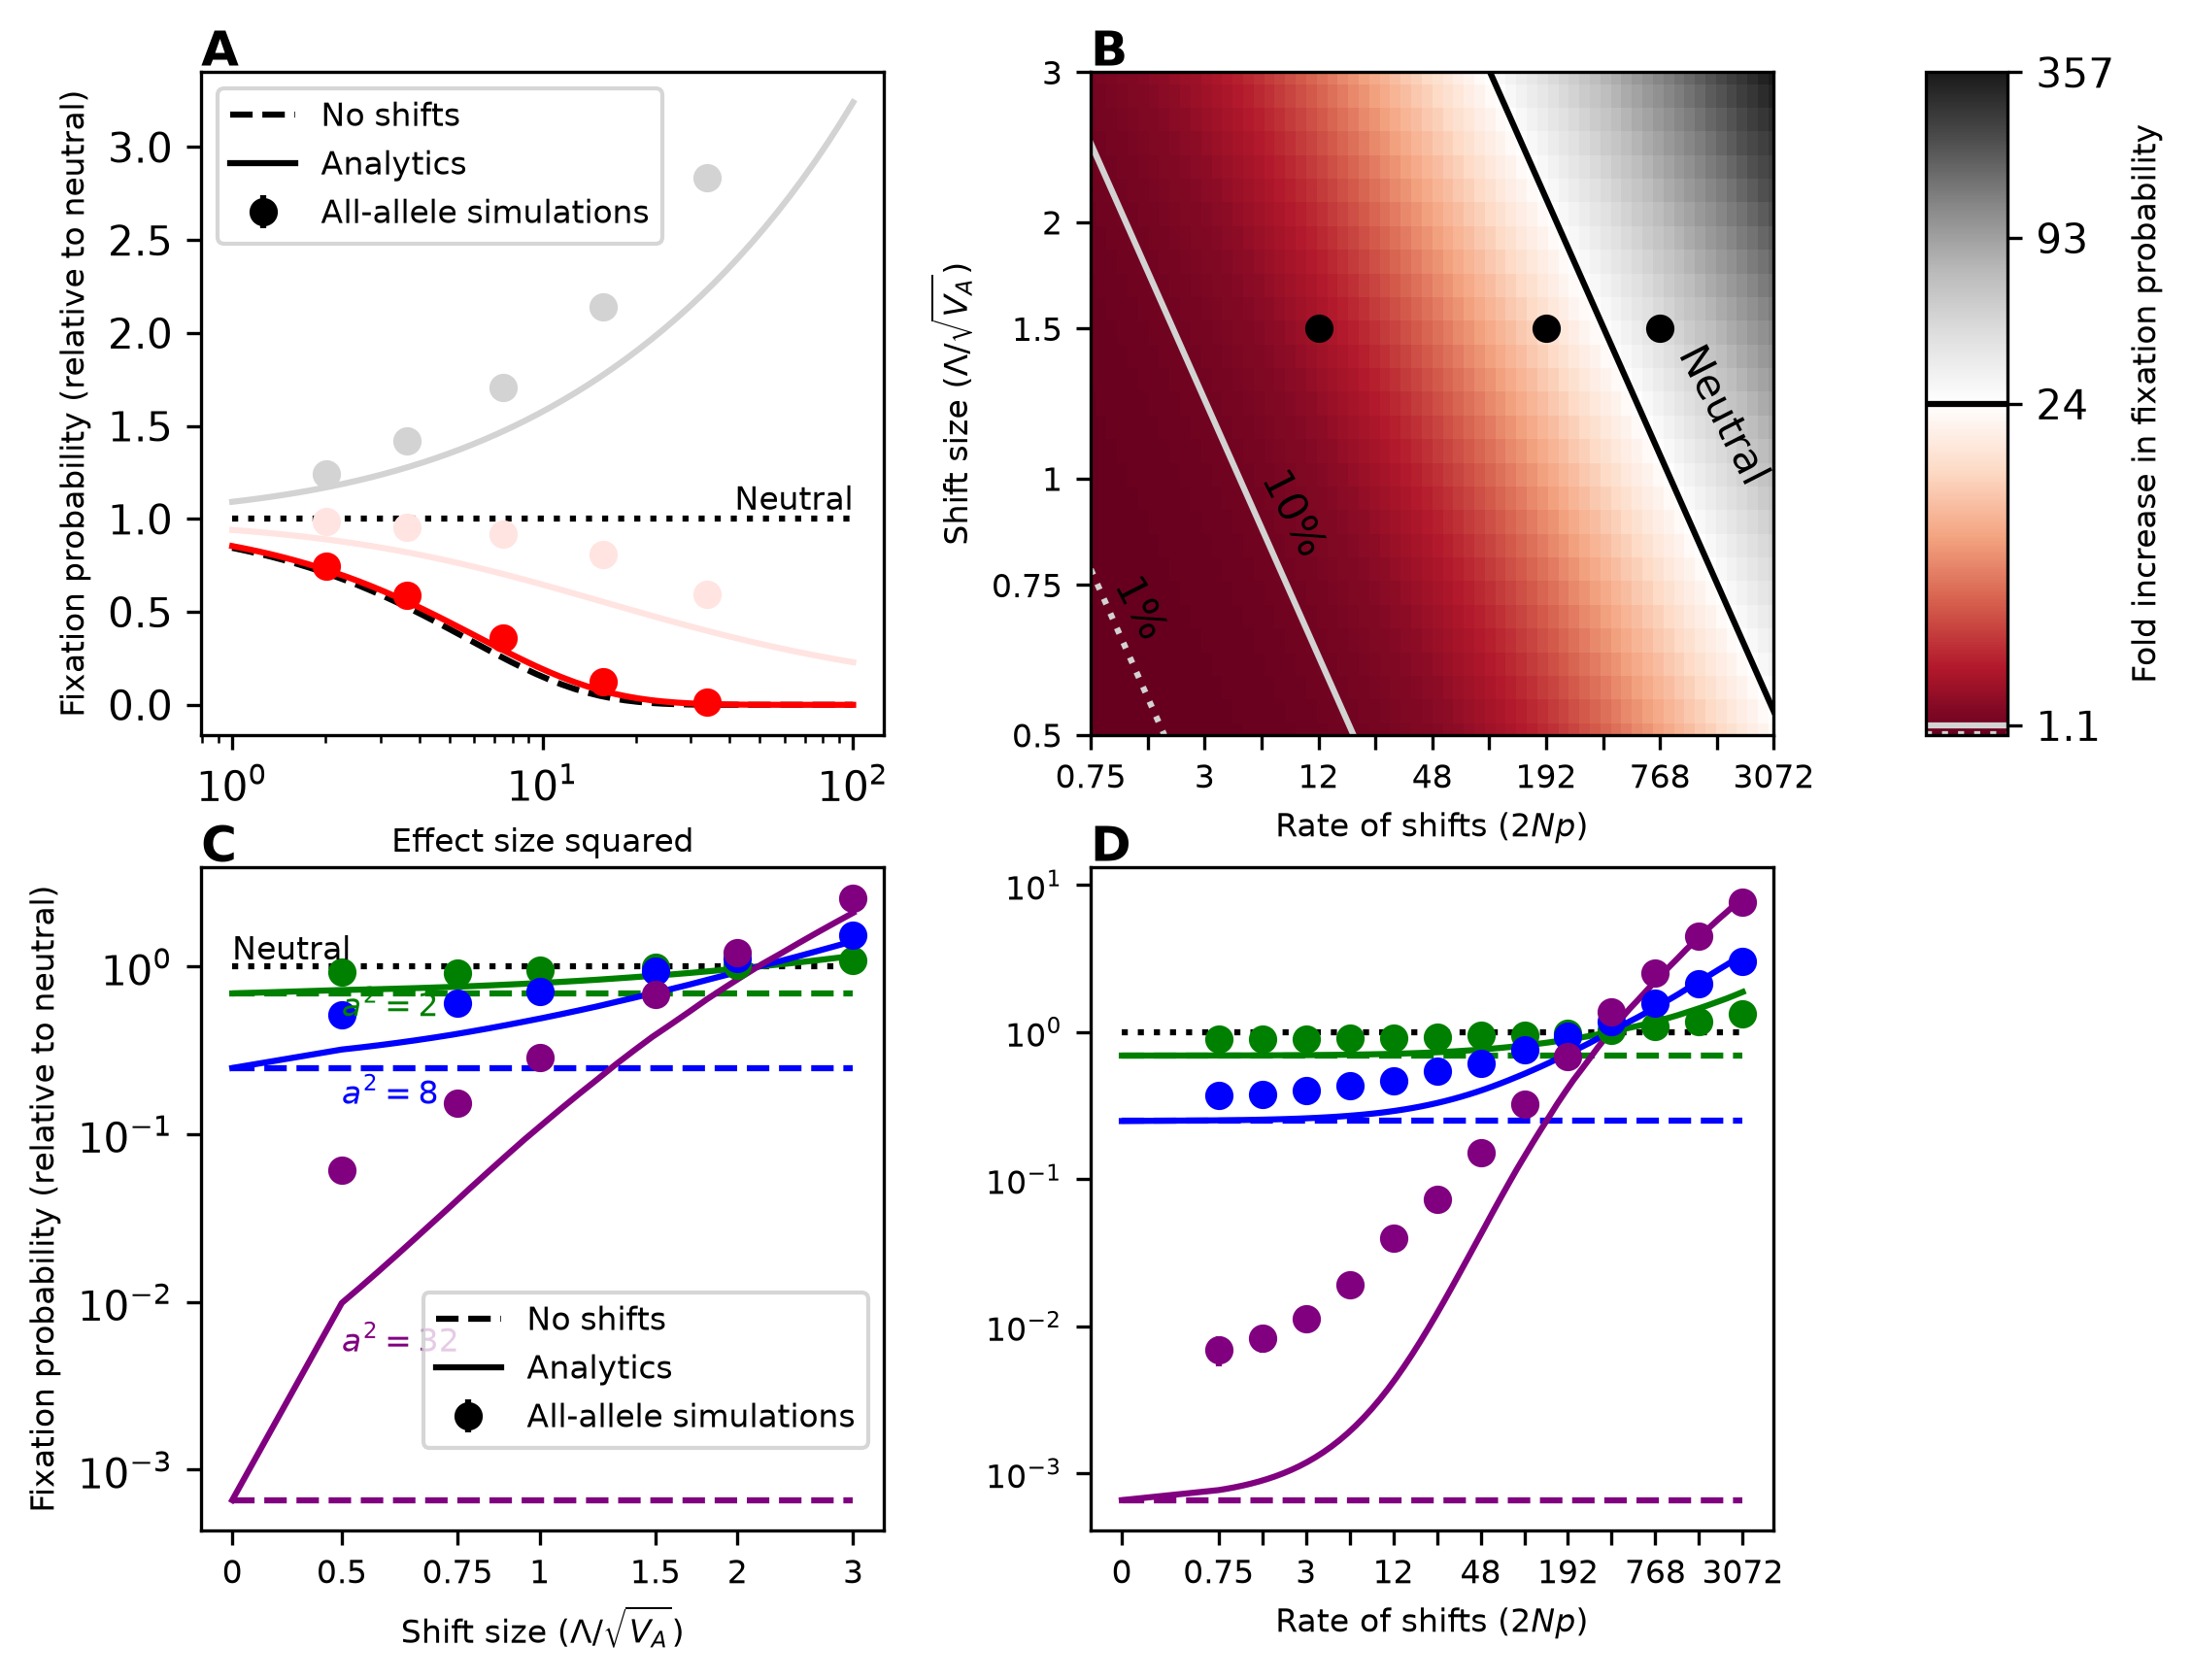

In [9]:
# the fixation probability under recurrent shifts, in the non-Lande case
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.1, 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.1, round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))] if Z[-1, index_rate_of_shift] >= 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=1, y=0.75, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=6, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=960, y=1.4, s='Neutral', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

# panels C and D: the fixation probability as a function of the shift size (or the rate of shifts) for a given rate of shifts (or the shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'g'], [3, 7.55, 'b'], [9, 34.1, 'purple']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.multiply(fixation_probability_mean_wrt_shift_s0, 2 * N), yerr=np.multiply(fixation_probability_se_wrt_shift_s0, 1.96 * 2 * N), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.1, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.5, s='$a^2=%g$' % 2, color='g', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.15, s='$a^2=%g$' % 8, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.005, s='$a^2=%g$' % 32, color='purple', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(1., 0.1), loc='lower right', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'g'], [3, 7.55, 'b'], [9, 34.1, 'purple']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.multiply(fixation_probability_mean_wrt_rate_of_shifts, 2 * N), yerr=np.multiply(fixation_probability_se_wrt_rate_of_shifts, 1.96 * 2 * N), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_3668855/556621982.py:35: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


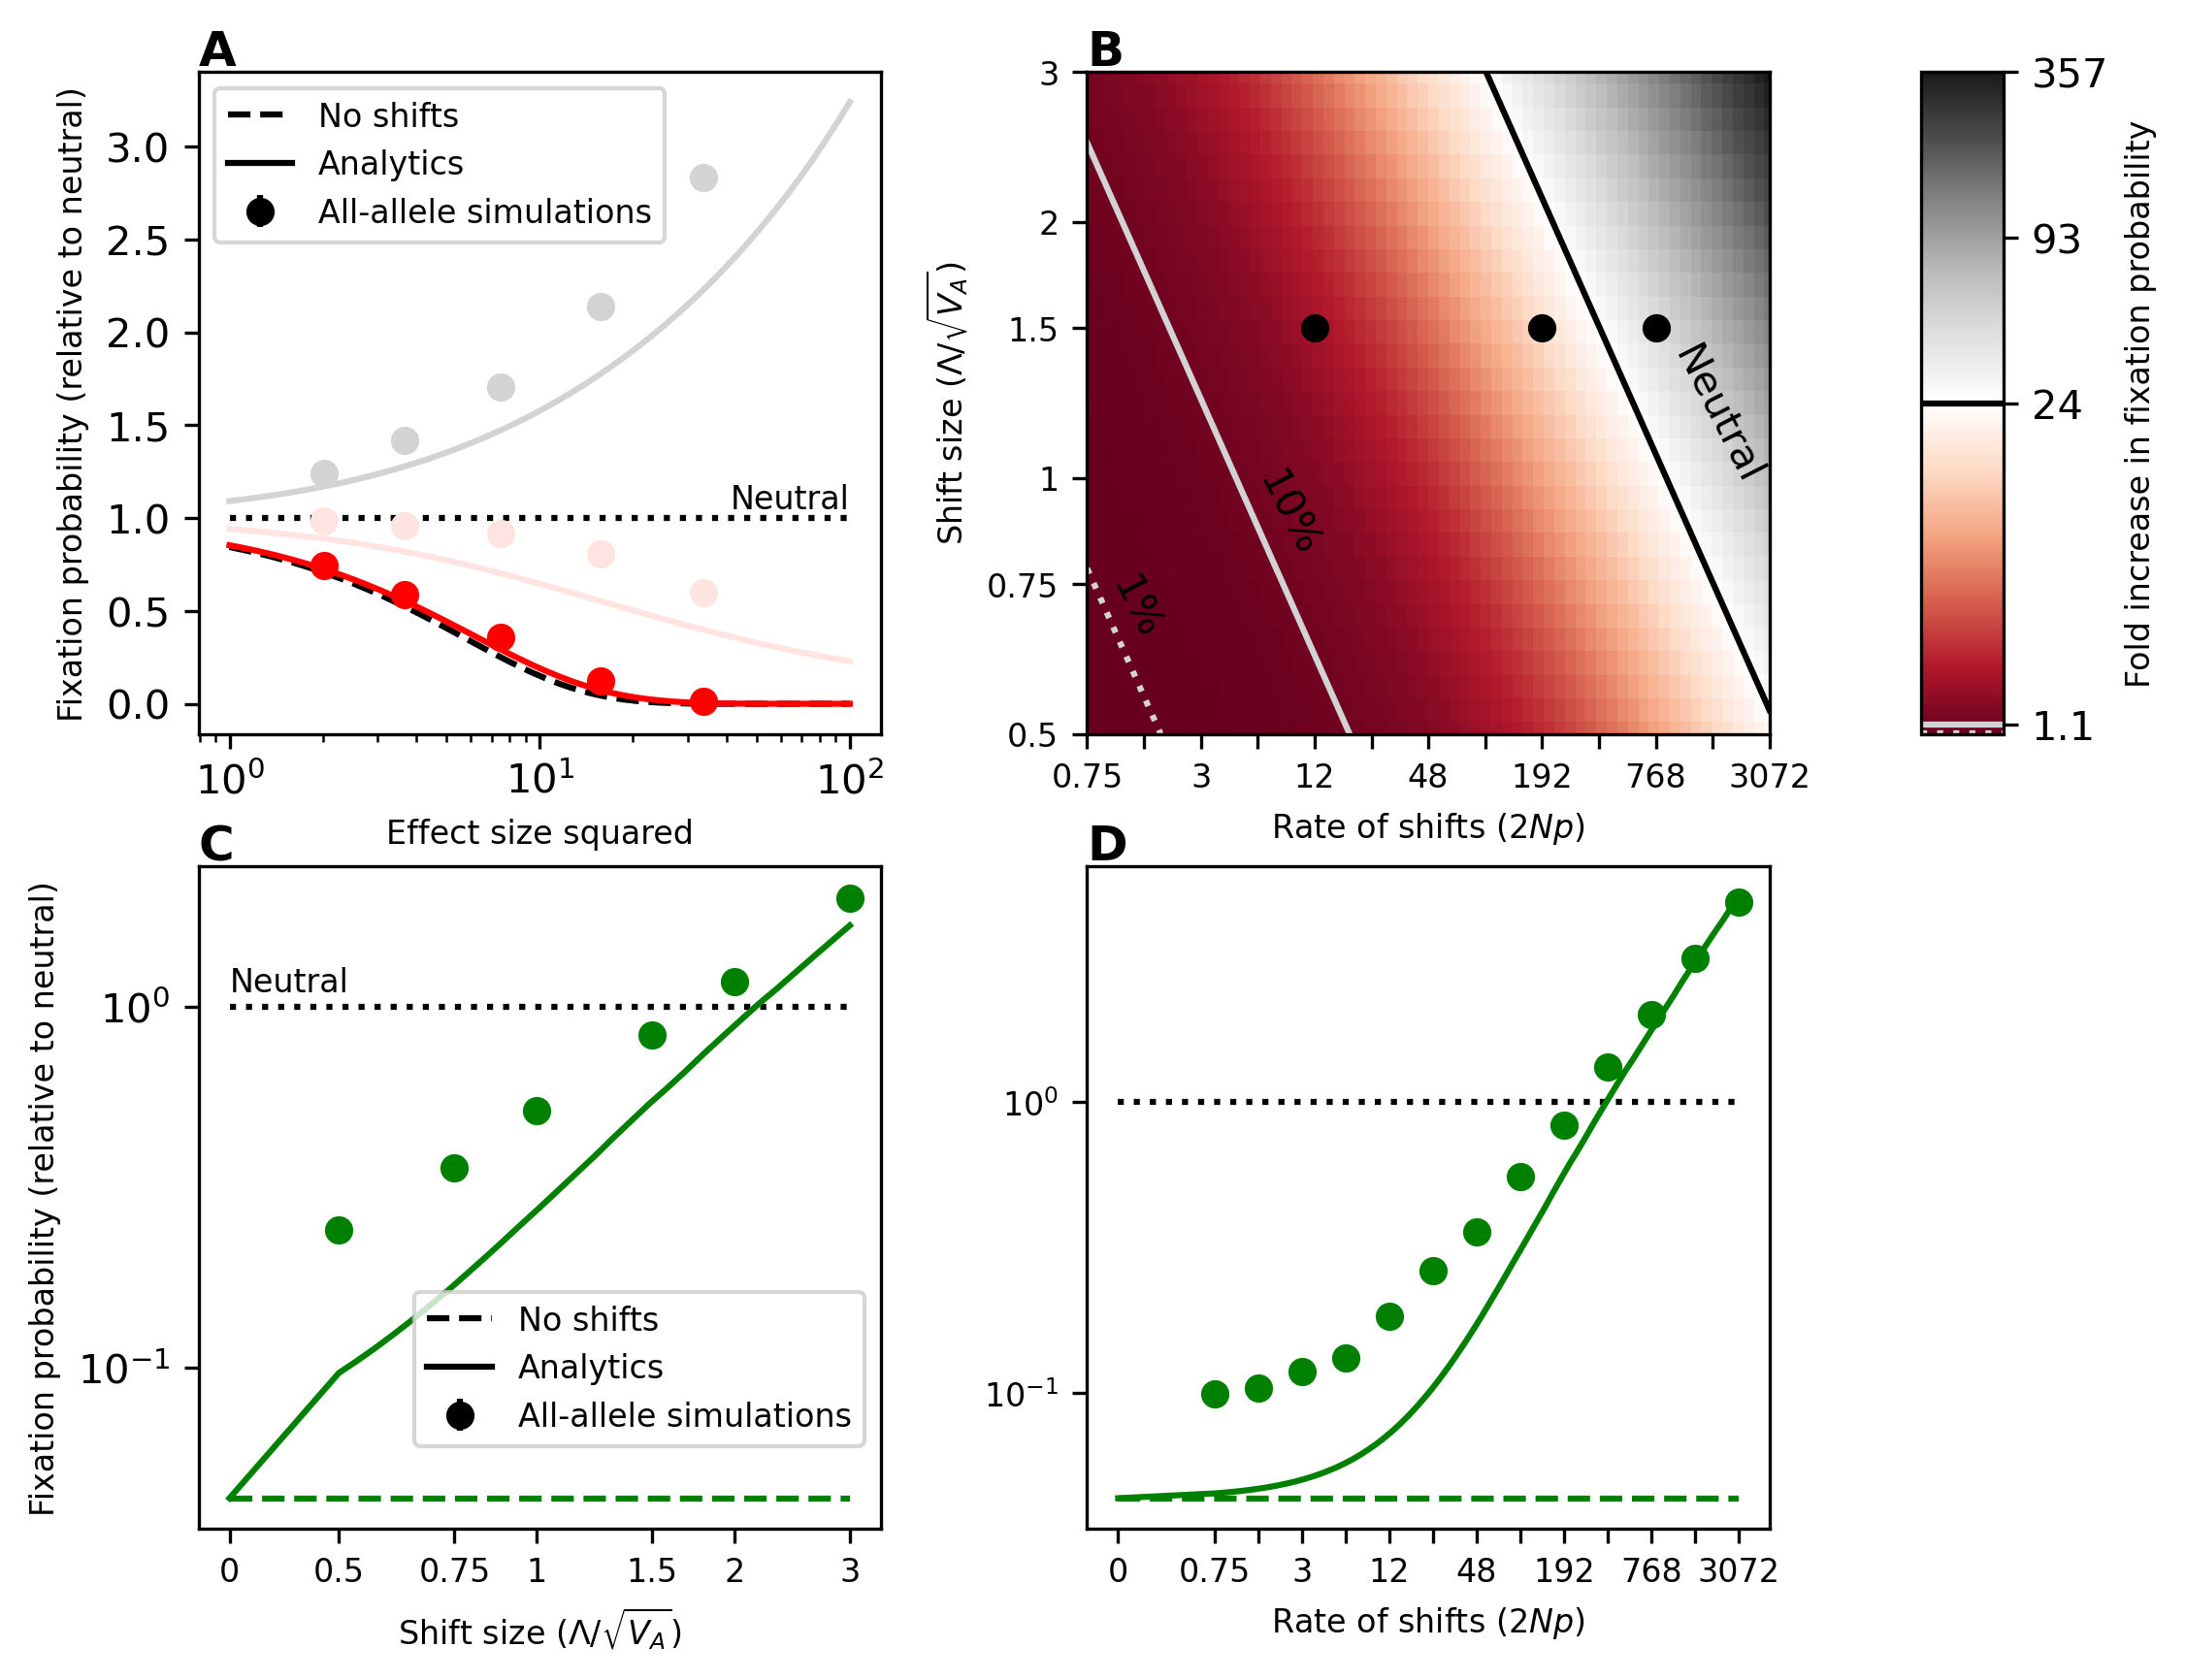

In [8]:
# the fixation probability under recurrent shifts, in the non-Lande case
# panels C and D: the average fixation probability over the effect size distribution
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.1, 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.1, round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='r')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='mistyrose')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color='lightgray')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))] if Z[-1, index_rate_of_shift] >= 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=1, y=0.75, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=6, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=960, y=1.4, s='Neutral', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

# panels C and D: the fixation probability as a function of the shift size (or the rate of shifts) for a given rate of shifts (or the shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate(((6, 15.8, 'g'), )):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, fixation_probability_mean_wrt_shift_s0 * 2 * N, yerr=1.96 * fixation_probability_se_wrt_shift_s0 * 2 * N, fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.1, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.5, s='$a^2=%g$' % 2, color='g', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.15, s='$a^2=%g$' % 8, color='b', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.005, s='$a^2=%g$' % 32, color='purple', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(1., 0.1), loc='lower right', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate(((6, 15.8, 'g'), )):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), fixation_probability_mean_wrt_rate_of_shifts * 2 * N, yerr=1.96 * fixation_probability_se_wrt_rate_of_shifts * 2 * N, fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/insomnia001/home/jc5473/my_code/plot_functions.py:65: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


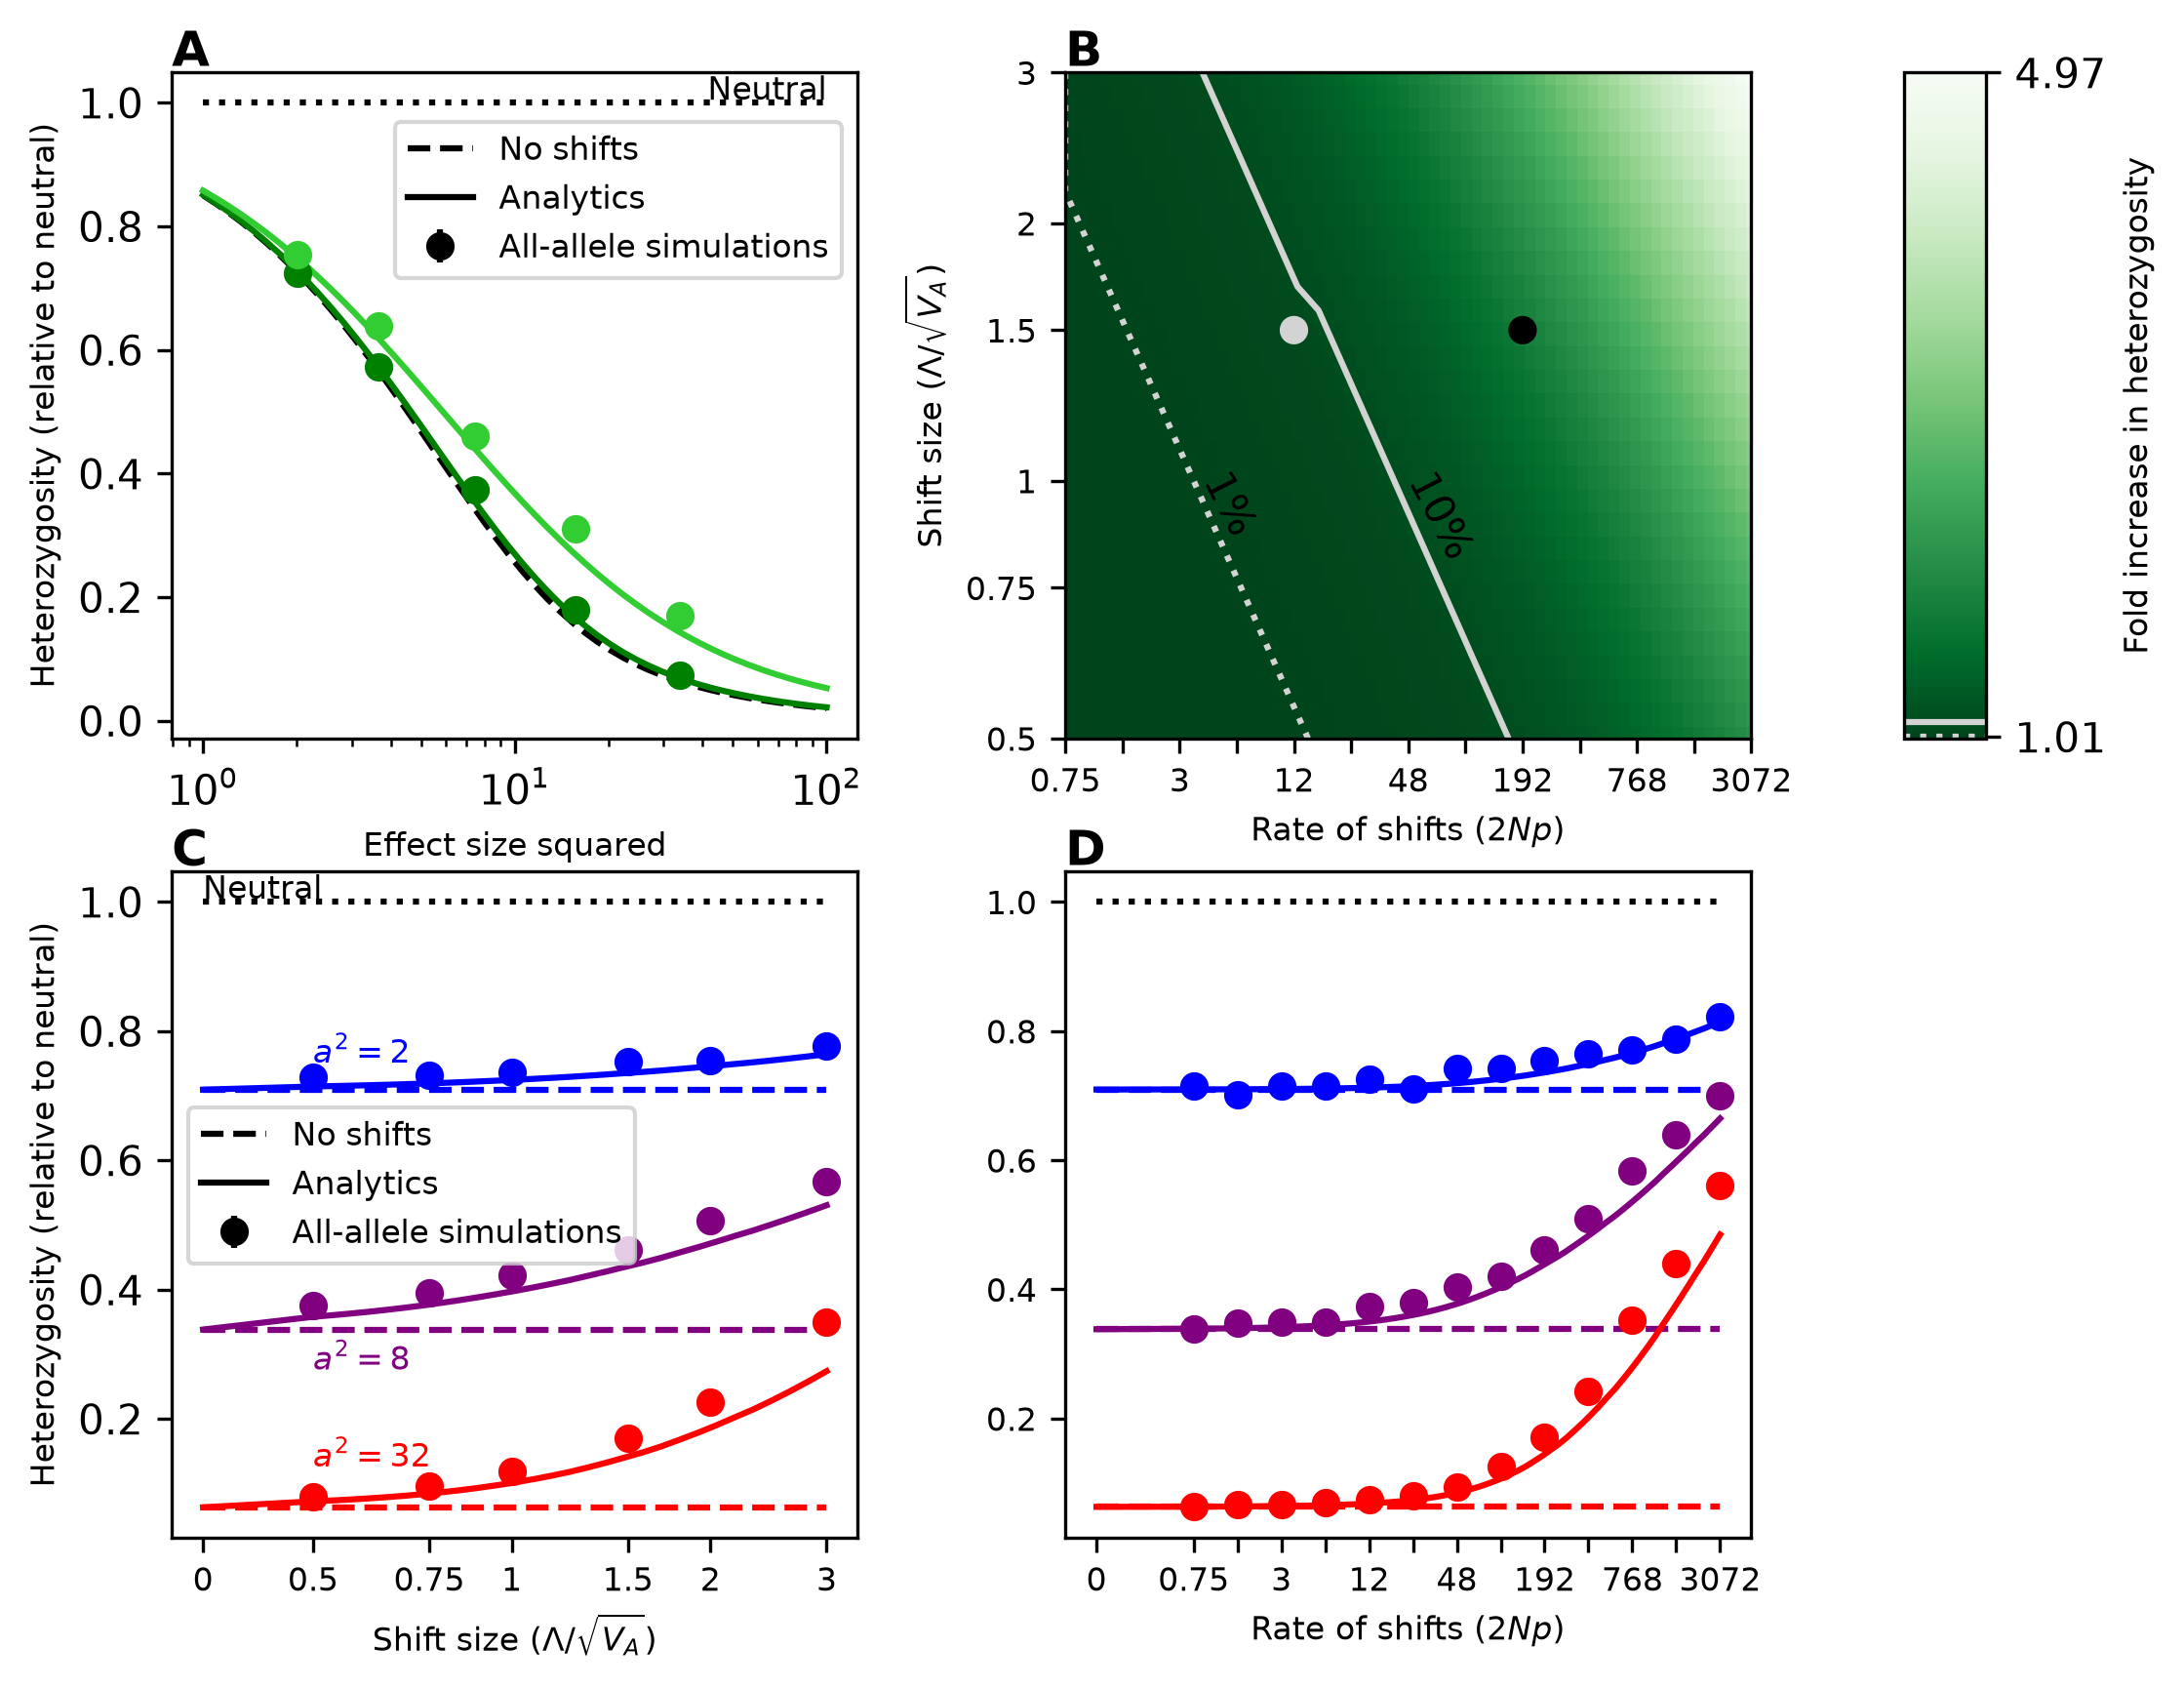

In [7]:
# the heterozygosity under recurrent shifts, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            Z[index_shift_s0, index_rate_of_shift] = pickle.load(f)
Z = np.divide(Z, heterozygosity_(a=np.sqrt(E2Ns)))
z_min, z_max = Z.min(), Z.max()

norm = colors.Normalize(vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='Greens_r', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in heterozygosity', fontsize=fontsize)
cbar.ax.set_yticks([1.01, z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % z_max])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color='limegreen')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='limegreen')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(1., 0.95), loc='upper right', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

norm = colors.Normalize(vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='Greens_r', norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.1)] if Z[index_shift_s0, -1] >= 1.1 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle='-')
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.01)] if Z[index_shift_s0, -1] >= 1.01 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=4, y=1, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=48, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048]), [1.5, 1.5], color=['lightgray', 'k'])

# panels C and D: the heterozygosity as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.75, s=r'$a^2=%g$' % 2, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.275, s=r'$a^2=%g$' % 8, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.125, s=r'$a^2=%g$' % 32, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.67), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

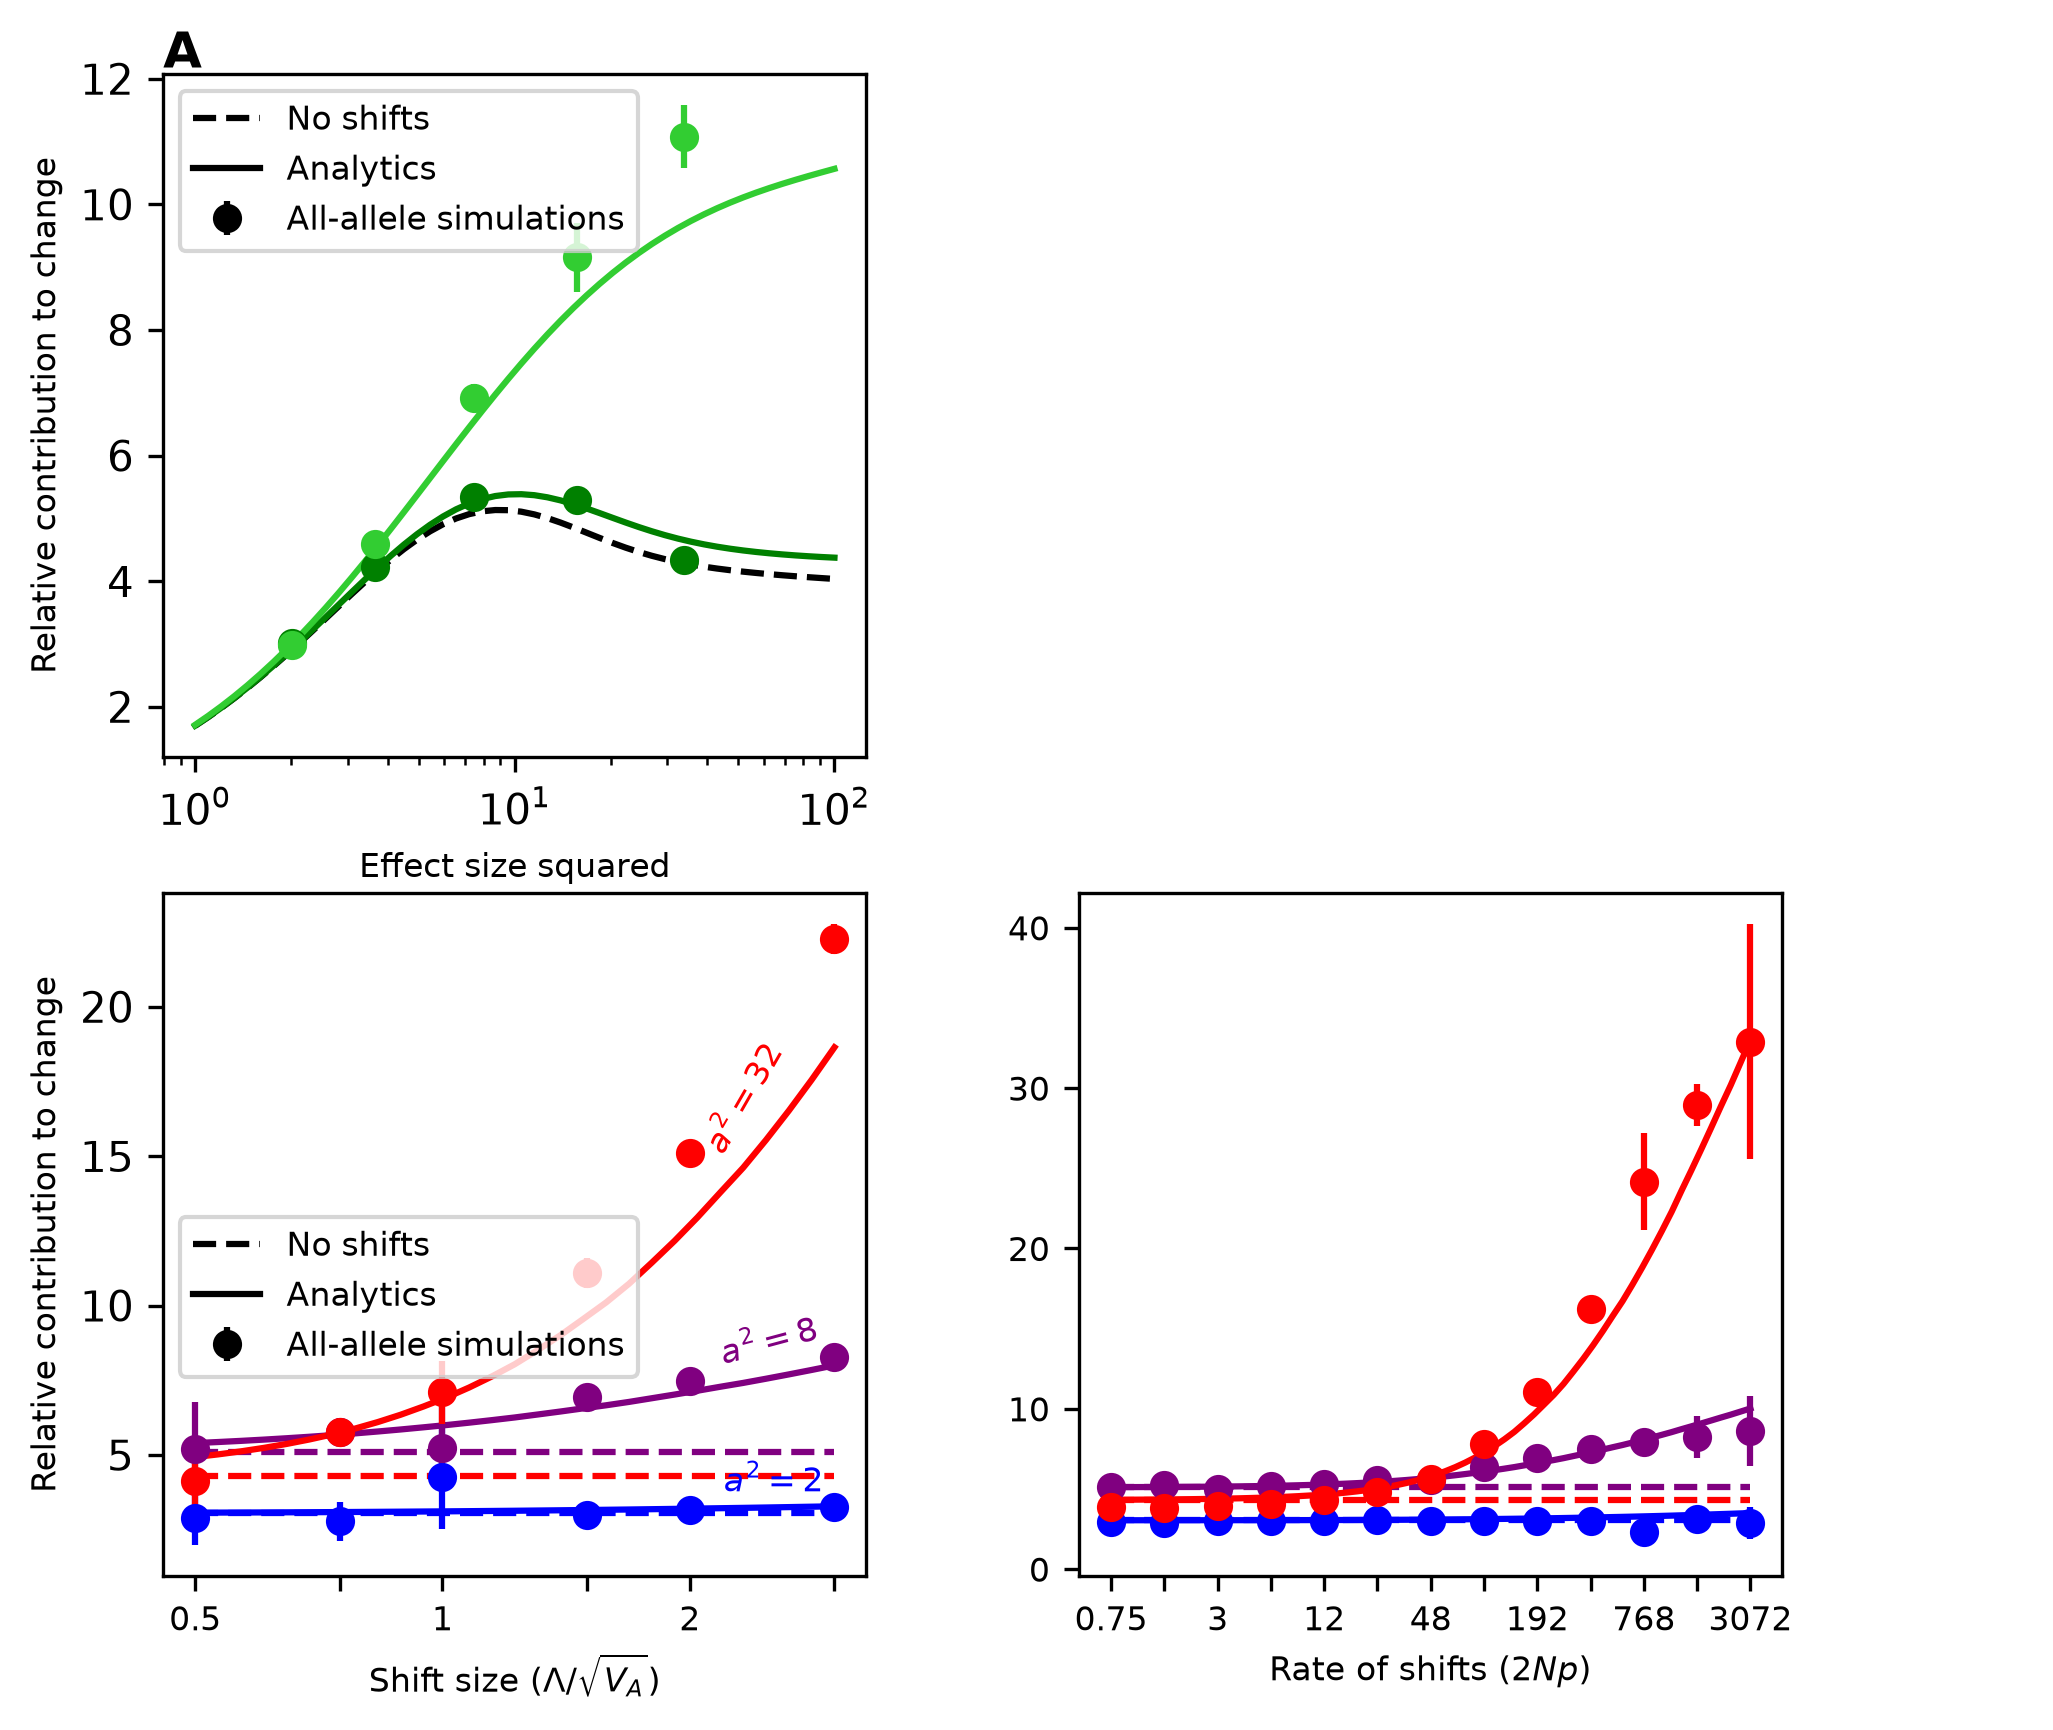

In [6]:
# the relative allelic contribution to the short-term phenotypic change after a shift, in the non-Lande case
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

no_shifts, = ax.plot(np.geomspace(1, 100), [v_(a=np.sqrt(ss)) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

# contribution_to_change_mean, contribution_to_change_se = calculate_contribution_to_change_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, E2Ns=E2Ns, nE=nE)
with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_mean = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_se = pickle.load(f)

ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(contribution_to_change_mean, (2 * N * U / (nE + 1))), yerr=1.96 * np.divide(contribution_to_change_se, (2 * N * U / (nE + 1))), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

# contribution_to_change_mean, contribution_to_change_se = calculate_contribution_to_change_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, E2Ns=E2Ns, nE=nE)
with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_mean = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d' % round(E2Ns), 'rb') as f:
    contribution_to_change_se = pickle.load(f)

ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(contribution_to_change_mean, (2 * N * U / (nE + 1))), yerr=1.96 * np.divide(contribution_to_change_se, (2 * N * U / (nE + 1))), fmt='o', color='limegreen')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='limegreen')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# Graph II for relative contribution to short-term phenotypic adaptation (w.r.t. shift size & w.r.t. rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])

index_rate_of_shift, rate_of_shift = 44, 0.048

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    # contribution_to_change_mean_wrt_shift_s0, contribution_to_change_se_wrt_shift_s0 = calculate_contribution_to_change_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, E2Ns=E2Ns, nE=nE)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_wrt_shift_s0_N_%d_U_' % N + str(U).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_mean_wrt_shift_s0 = pickle.load(f)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_wrt_shift_s0_N_%d_U_' % N + str(U).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_se_wrt_shift_s0 = pickle.load(f)
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(contribution_to_change_mean_wrt_shift_s0, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_shift_s0, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [v_(a=np.sqrt(ss)) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=2.2, y=3.75, s=r'$a^2=%g$' % 2, color='b', fontsize=fontsize)
ax.text(x=2.2, y=8, s=r'$a^2=%g$' % 8, rotation=15, rotation_mode='anchor', color='purple', fontsize=fontsize)
ax.text(x=2.2, y=15, s=r'$a^2=%g$' % 32, rotation=60, rotation_mode='anchor', color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.55), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])

index_shift_s0, shift_s0 = 17, 1.5

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    # contribution_to_change_mean_wrt_rate_of_shifts, contribution_to_change_se_wrt_rate_of_shifts = calculate_contribution_to_change_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, E2Ns=E2Ns, nE=nE)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_mean_wrt_rate_of_shifts_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_mean_wrt_rate_of_shifts = pickle.load(f)
    with open('/insomnia001/depts/pas_lab/users/jc5473/contribution_to_change_se_wrt_rate_of_shifts_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_E2Ns_%d_nE_%d_index_ss_%d' % (round(E2Ns), nE, index_ss), 'rb') as f:
        contribution_to_change_se_wrt_rate_of_shifts = pickle.load(f)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(contribution_to_change_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [v_(a=np.sqrt(ss)) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/insomnia001/home/jc5473/my_code/plot_functions.py:65: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


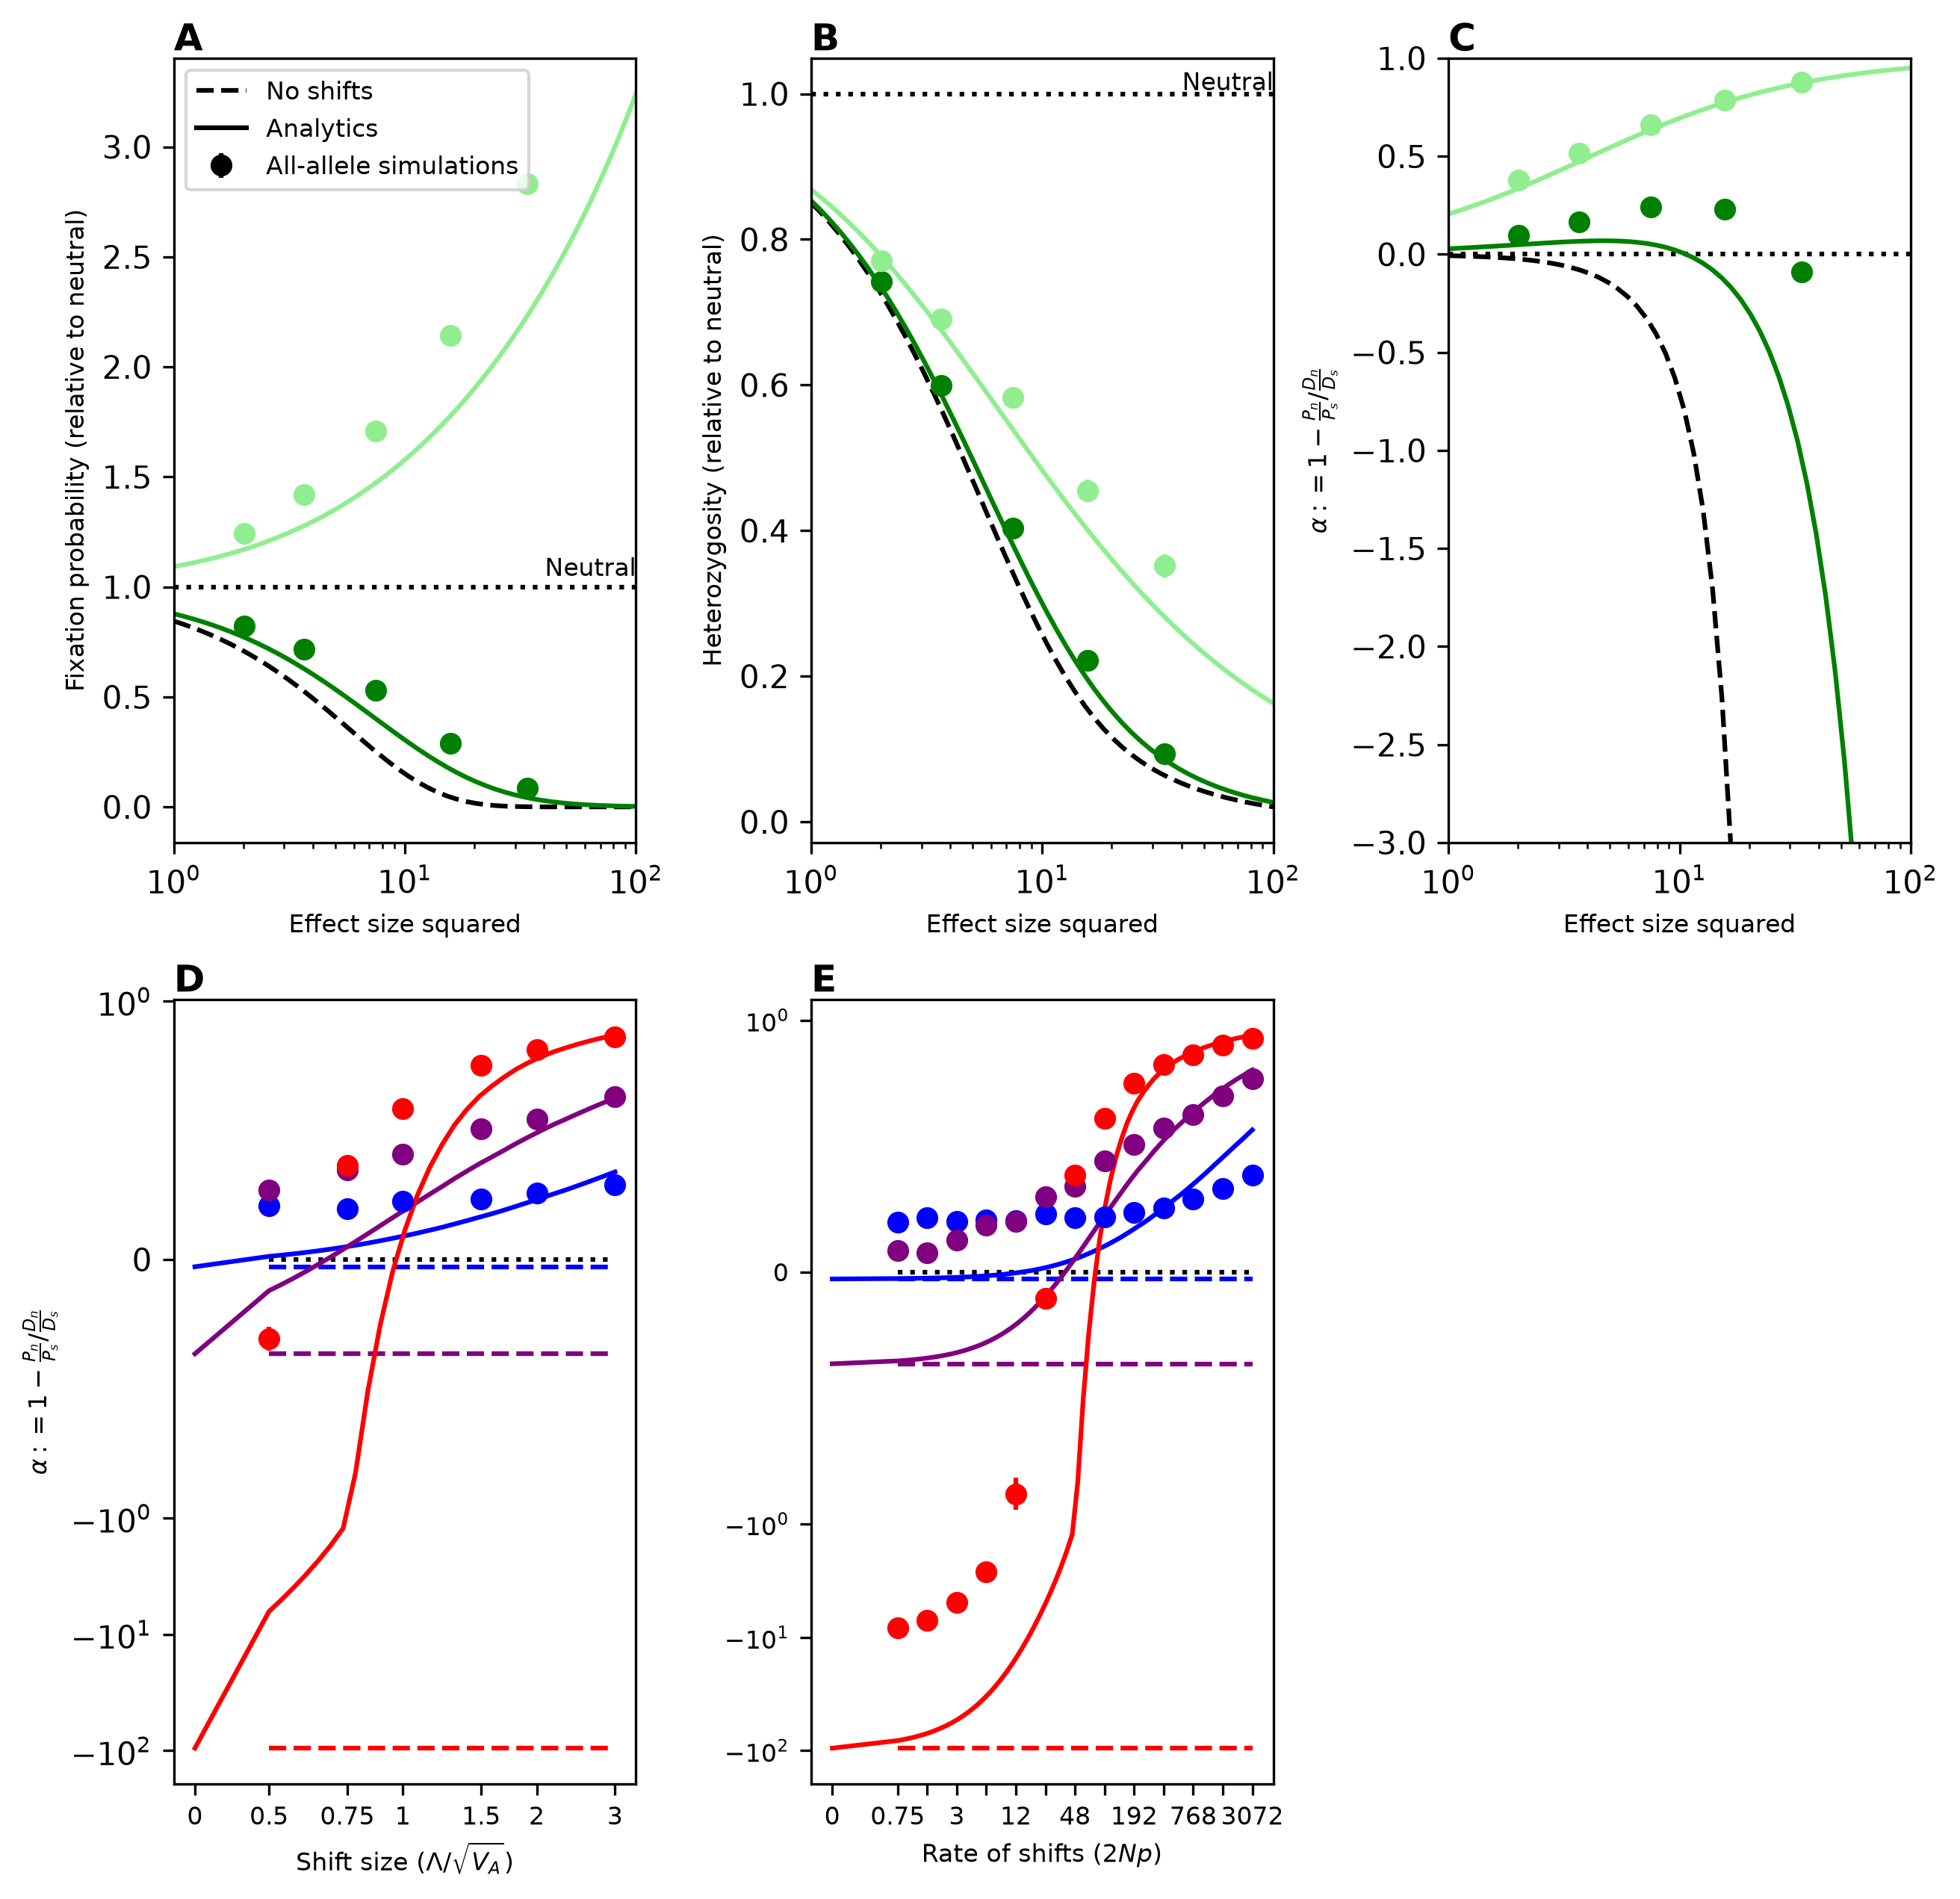

In [8]:
# McDonald-Kreitman test, in the non-Lande case
# without frequency cutoff
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

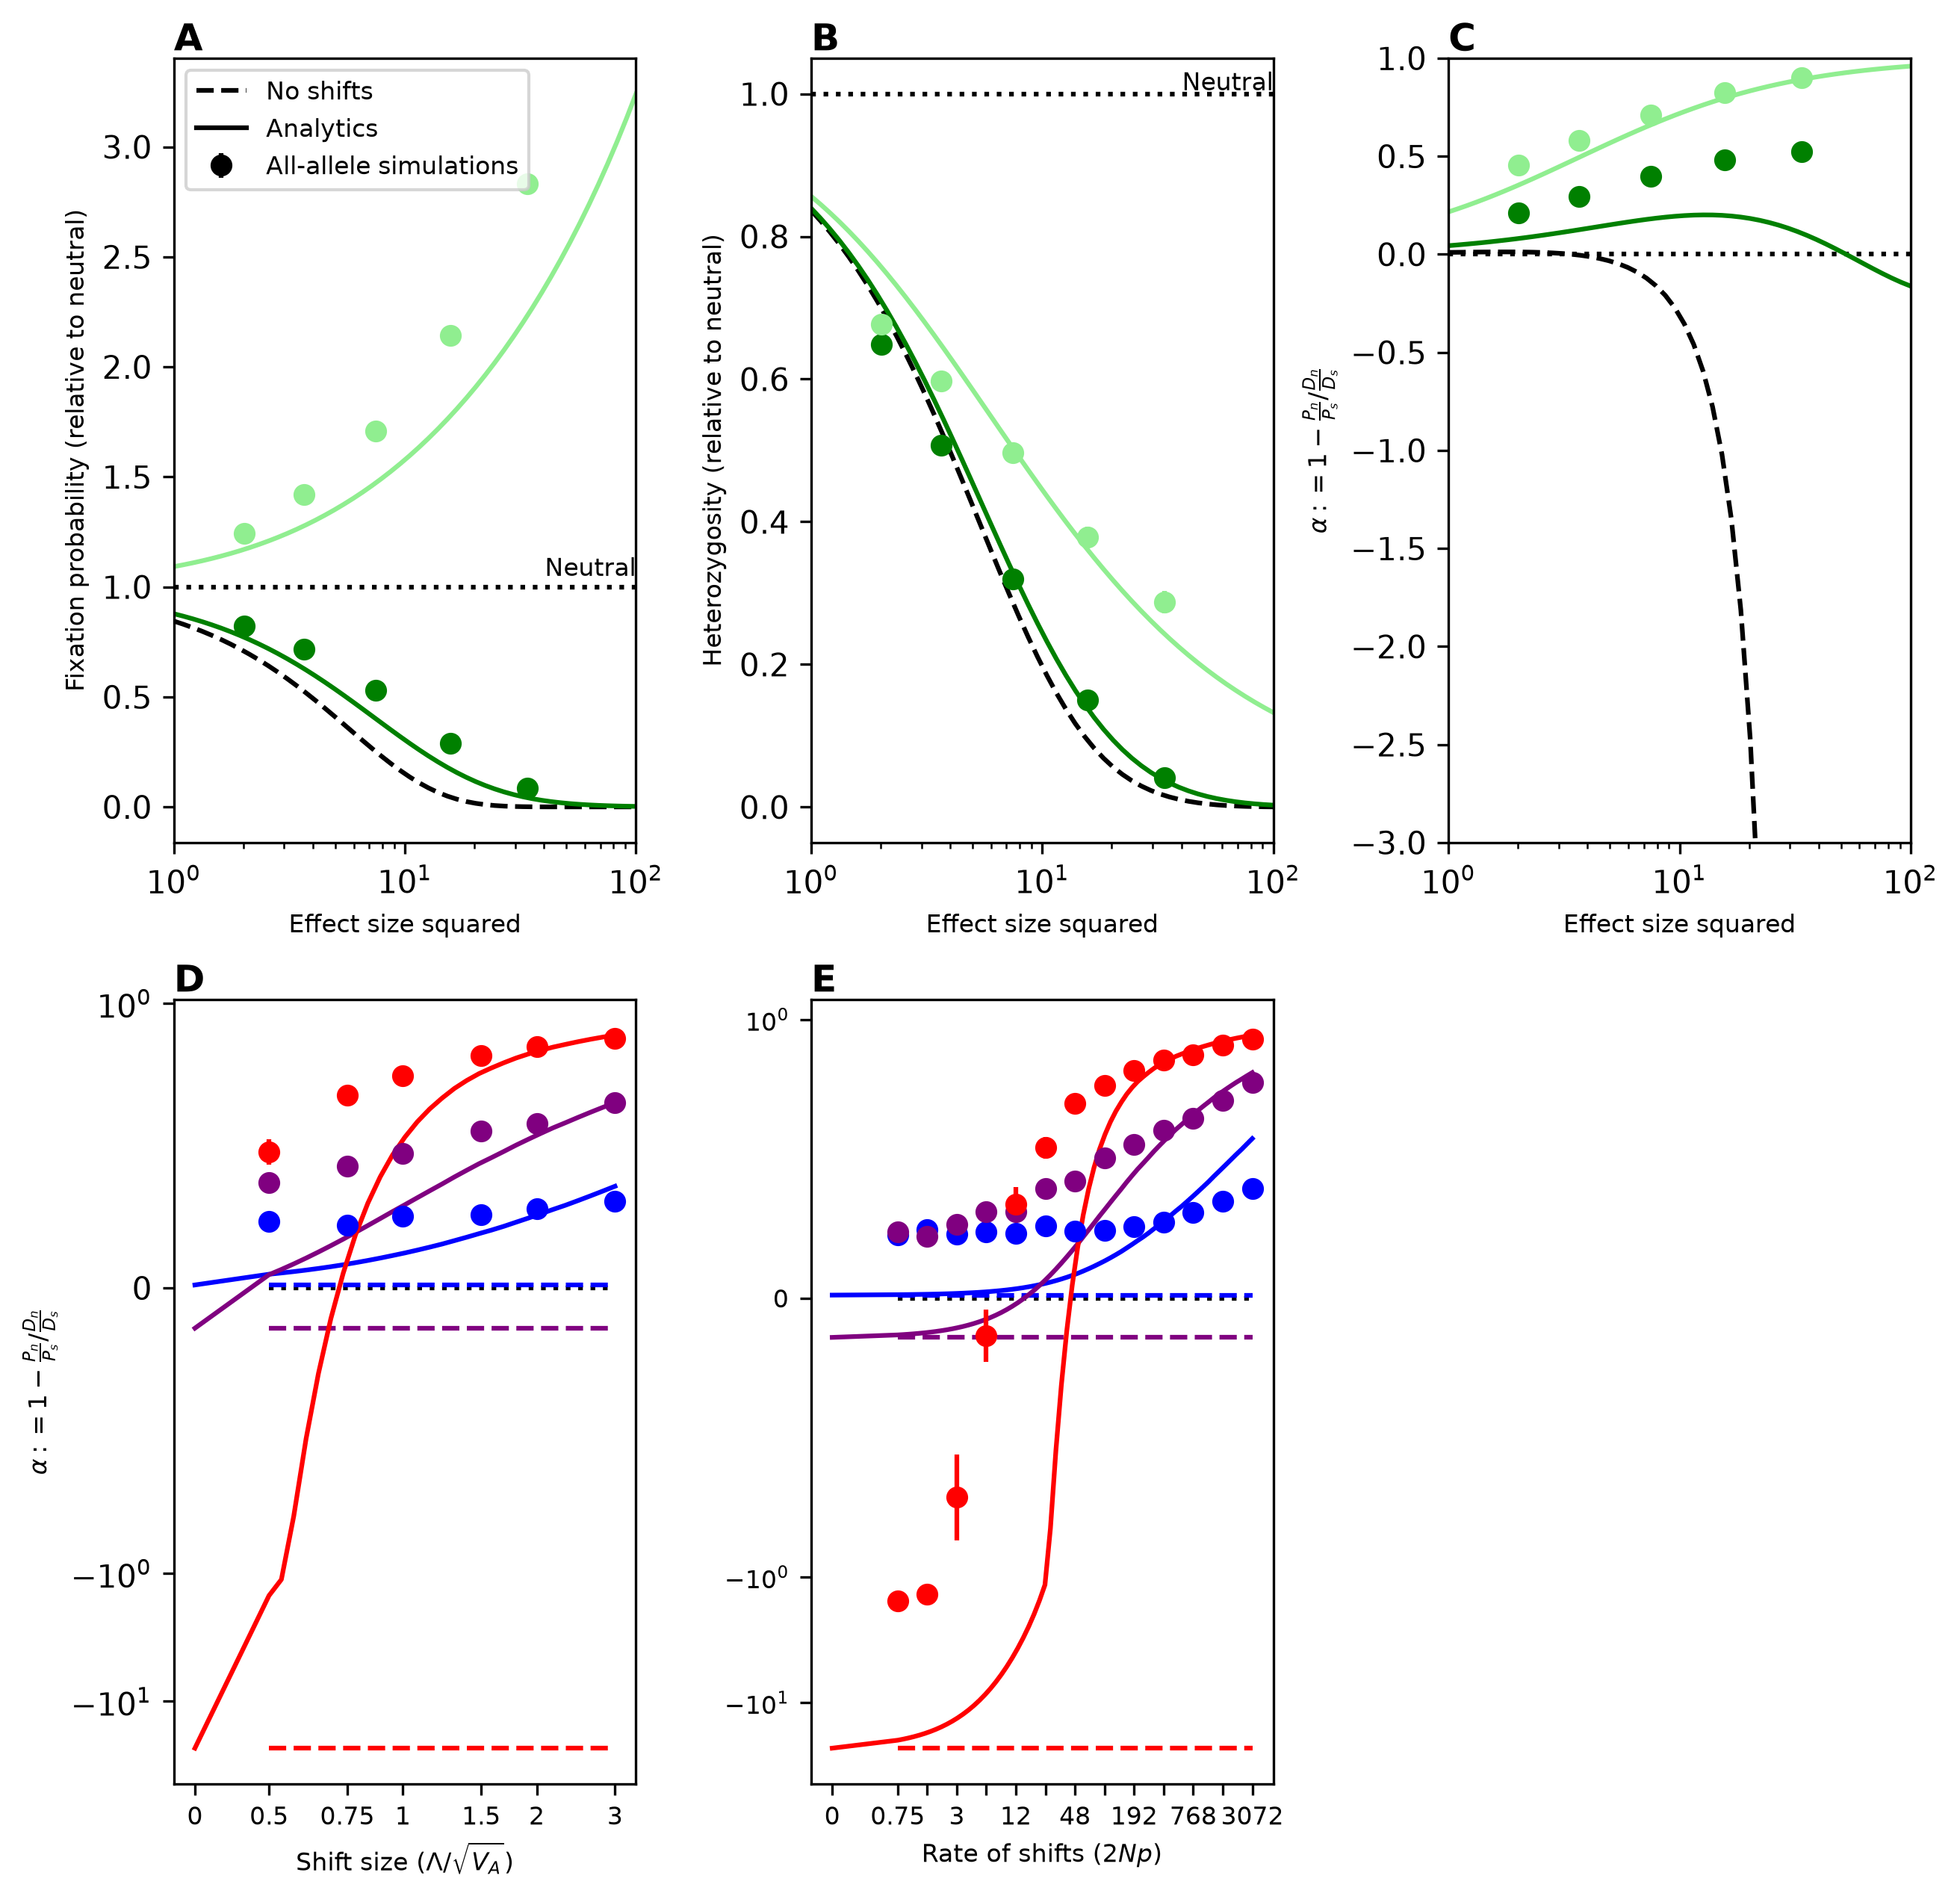

In [6]:
# McDonald-Kreitman test, in the non-Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

maf_threshold = 0.05

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE, maf_threshold=maf_threshold)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

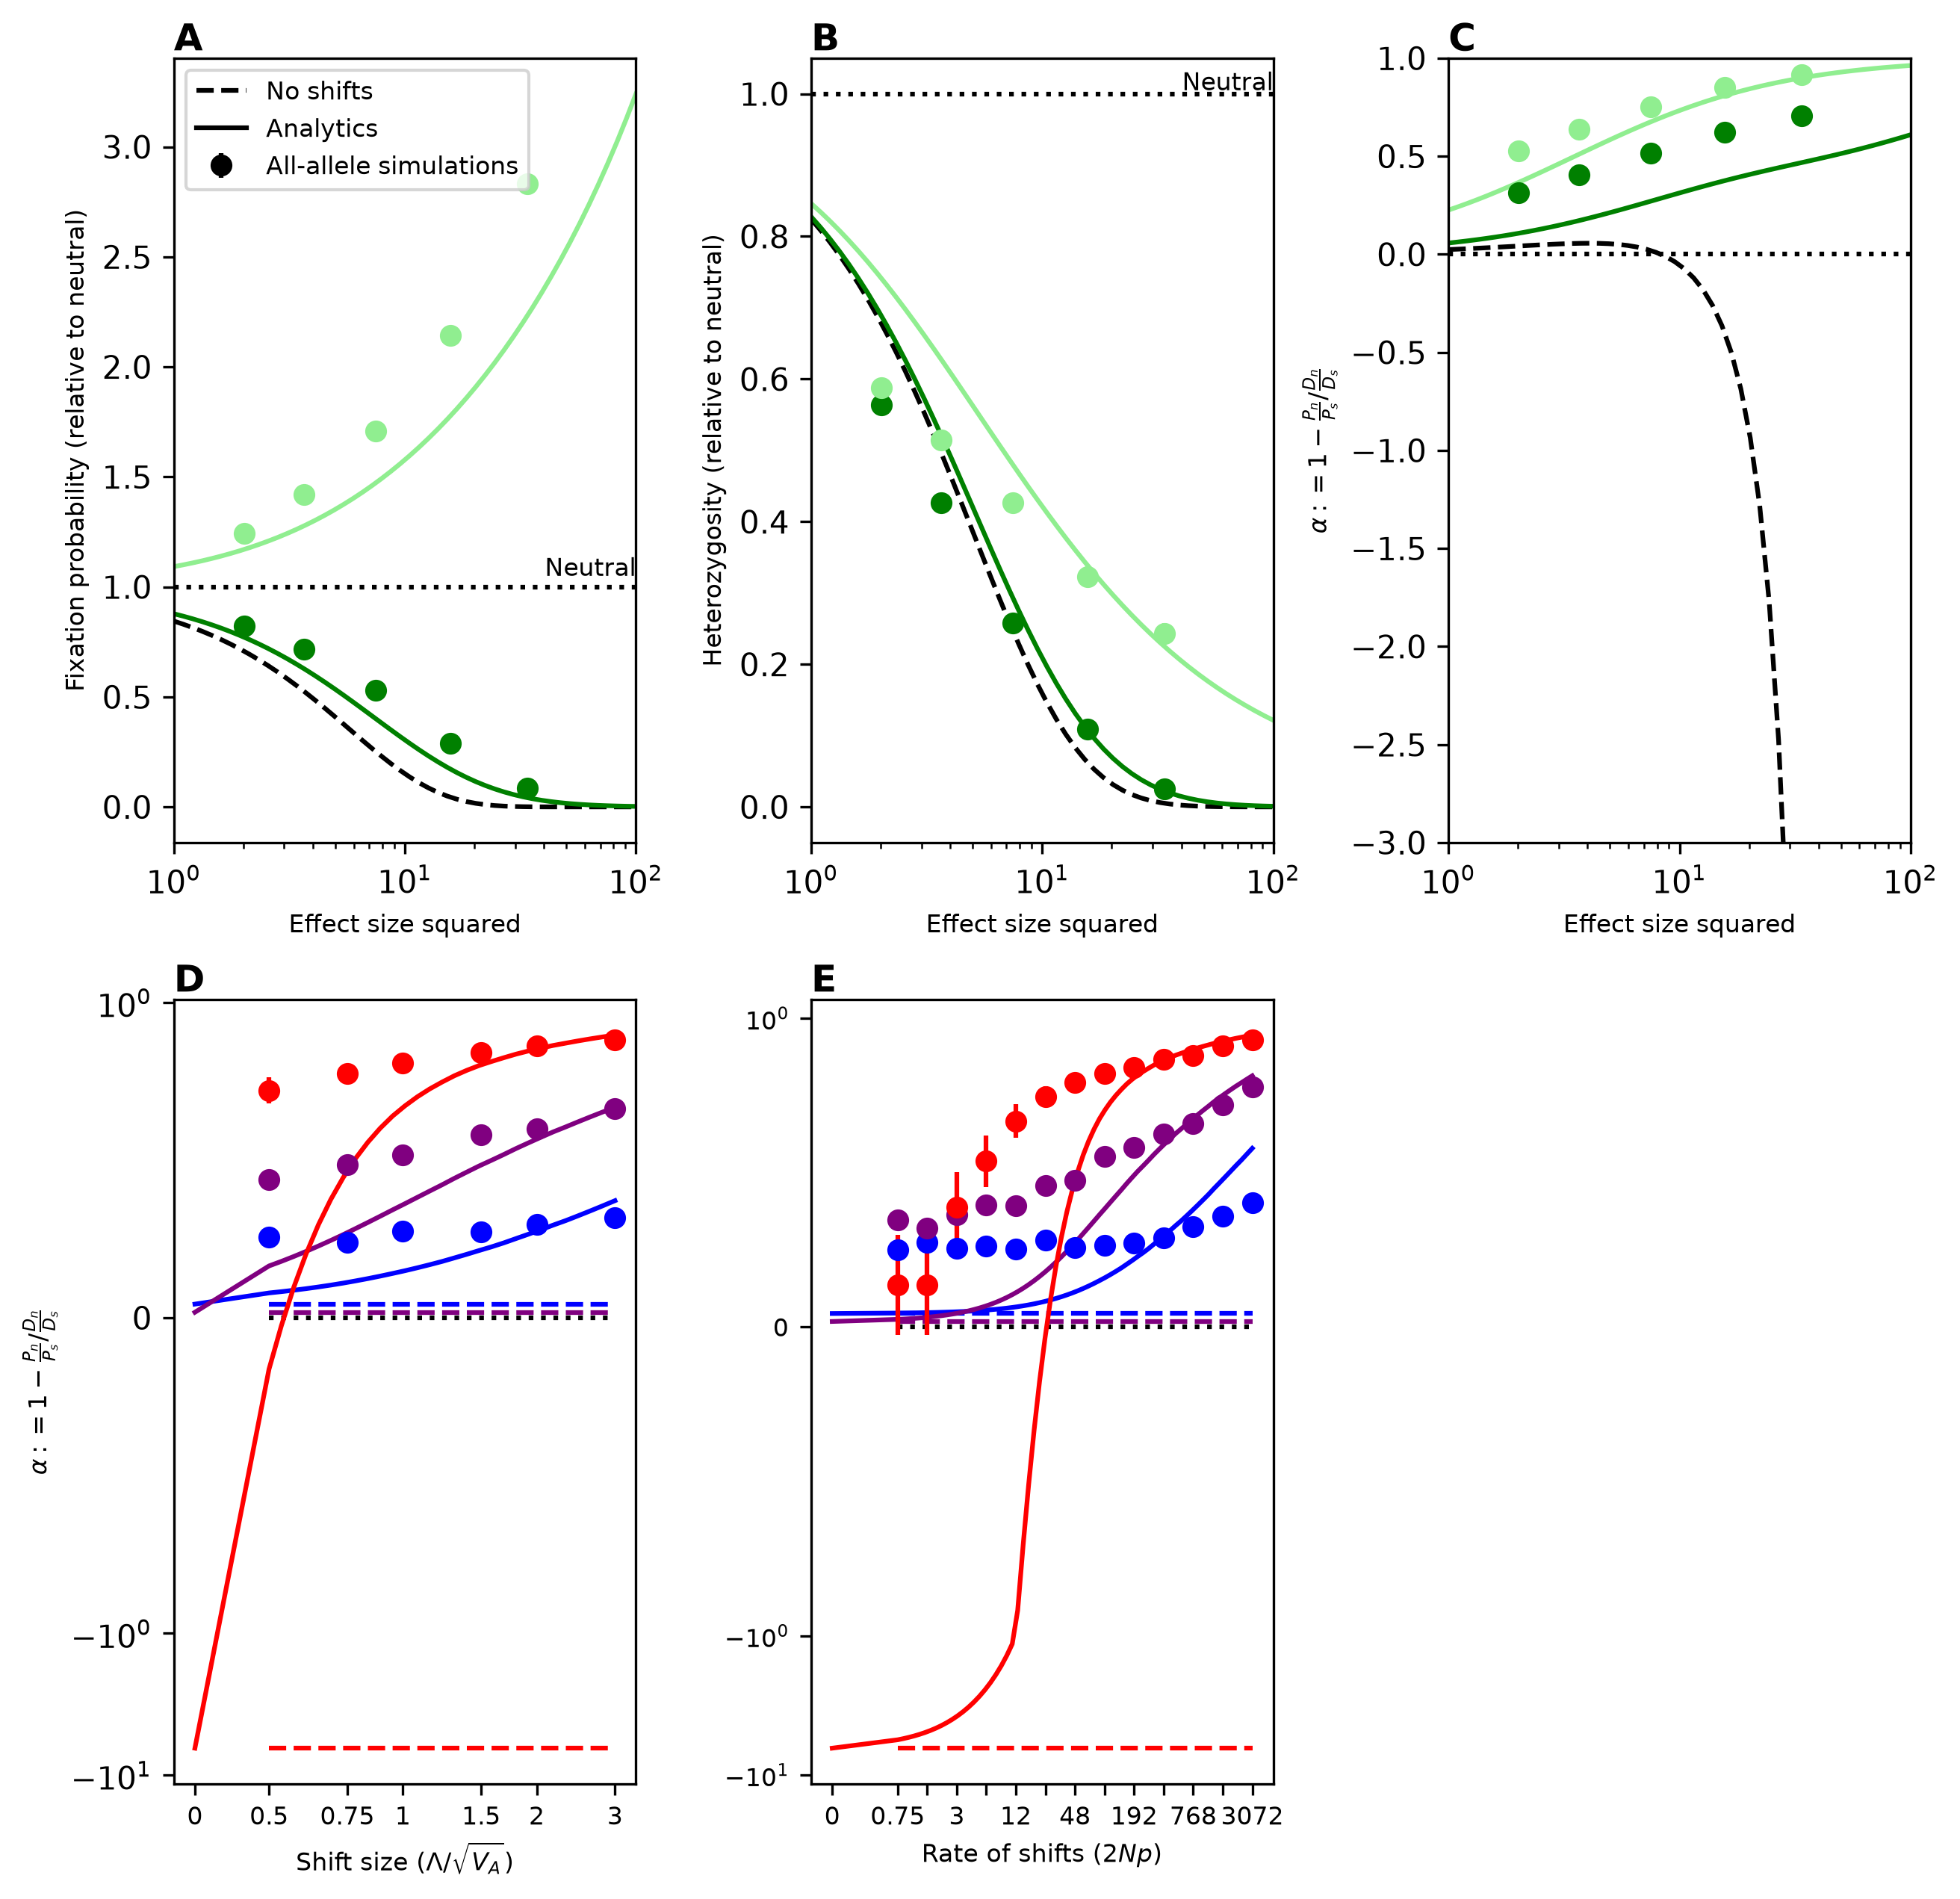

In [7]:
# McDonald-Kreitman test, in the non-Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

maf_threshold = 0.1

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    fixation_probability_mean, fixation_probability_se = calculate_fixation_probability_mean_and_se_across_effect_sizes_from_num_fixed_and_num_new_mutations(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, num_new_mutations=num_new_mutations, nE=nE)
    ax = plt.subplot(gs[0, 0])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.multiply(fixation_probability_mean, 2 * N), yerr=np.multiply(fixation_probability_se, 1.96 * 2 * N), fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_mean, heterozygosity_se = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_effect_sizes(my_AA_directories=['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)], indices_ss=indices_ss, nE=nE, maf_threshold=maf_threshold)
    ax = plt.subplot(gs[0, 2])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1)), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.errorbar(np.square(a_list_pos_between)[indices_ss], np.subtract(1, np.divide(np.divide(heterozygosity_mean, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean)), yerr=1.96 * np.divide(np.divide(heterozygosity_se, (2 * N * U / (nE + 1)) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean), fmt='o', color=color)
    
# Graph II for the McDonald-Kreitman test (w.r.t. the shift size or the rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_shift_s0, fixation_probability_se_wrt_shift_s0 = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_shift_s0, heterozygosity_se_wrt_shift_s0 = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for shift_s0 in shift_s0_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    fixation_probability_mean_wrt_rate_of_shifts, fixation_probability_se_wrt_rate_of_shifts = calculate_fixation_probability_mean_and_se_across_shifts_from_num_fixed_and_num_new_mutations(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), i) for i in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, num_new_mutations=num_new_mutations, nE=nE)
    heterozygosity_mean_wrt_rate_of_shifts, heterozygosity_se_wrt_rate_of_shifts = calculate_heterozygosity_with_frequency_cutoff_mean_and_se_across_shifts(my_AA_directories_across_shifts=[['/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d' % (round(E2Ns), j) for j in range(1, 1 + parallel_AA)] for rate_of_shift in rate_of_shifts_list], index_ss=index_ss, nE=nE, maf_threshold=maf_threshold)
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

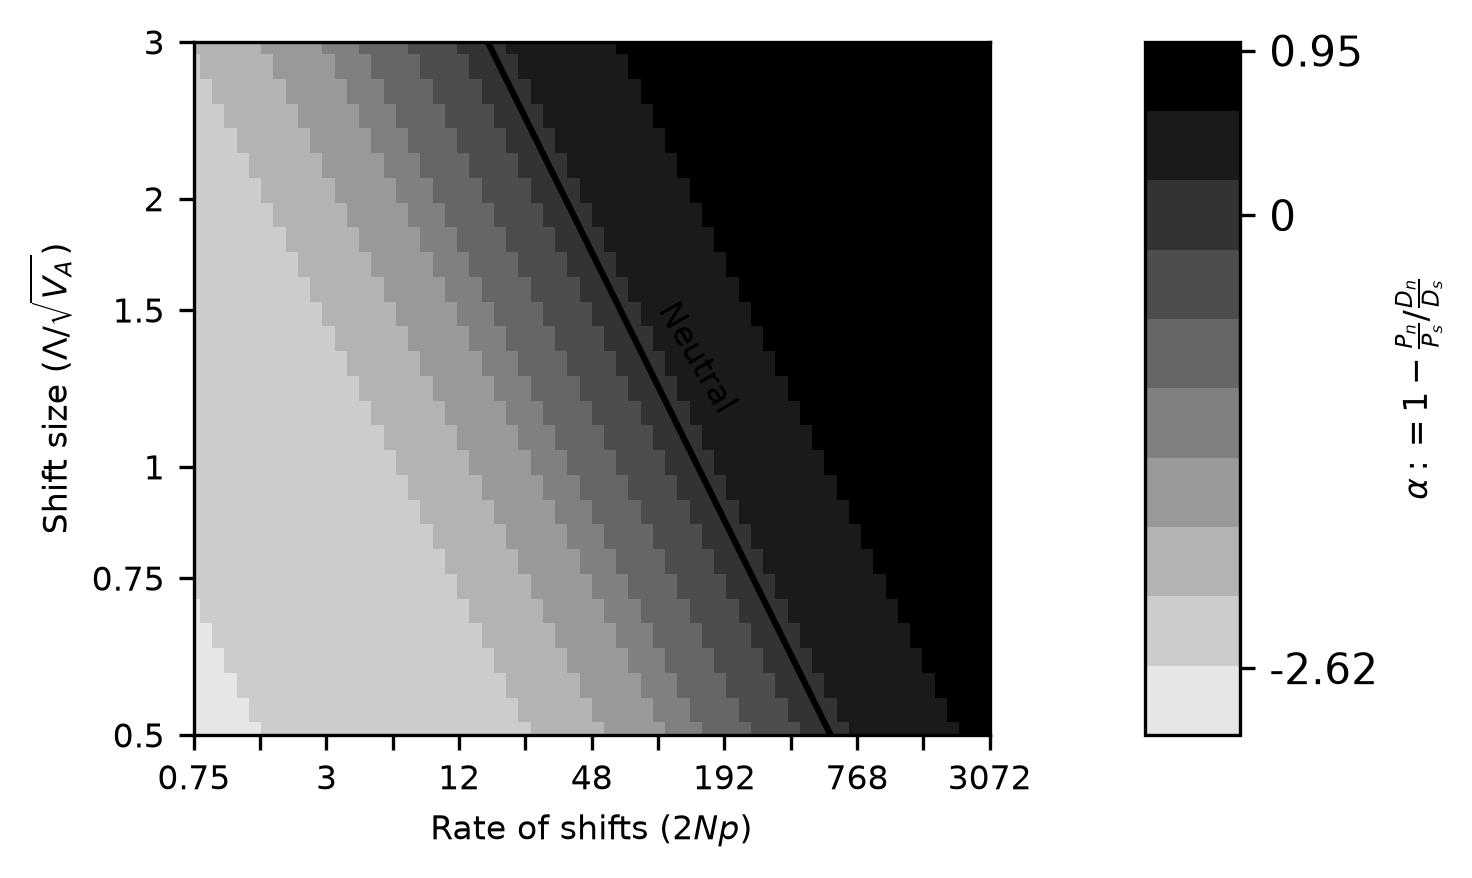

In [12]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-3., 1.05, 0.4)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

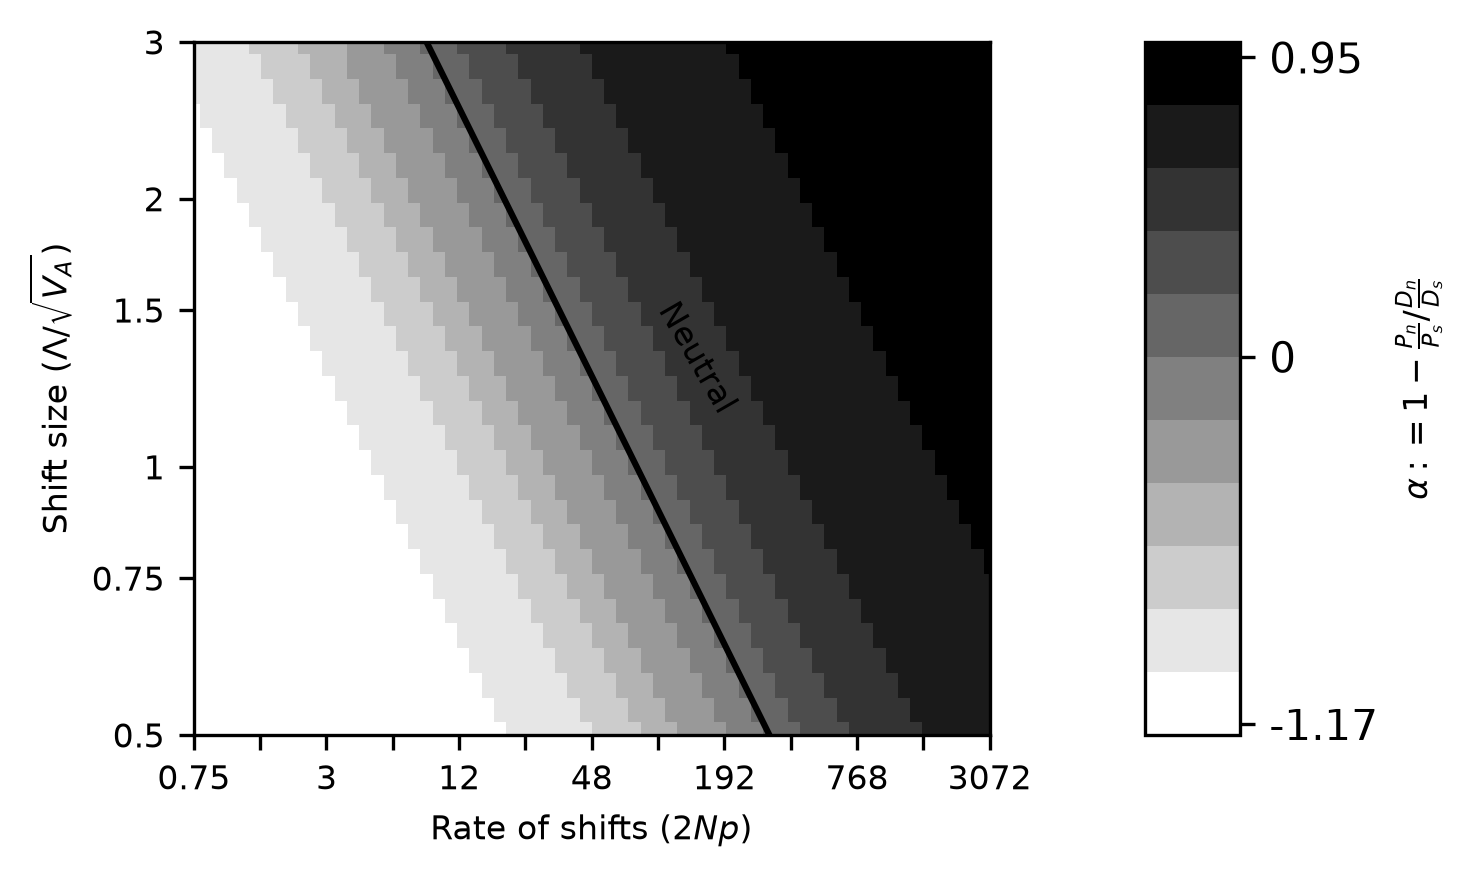

In [13]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

maf_threshold = 0.05

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['1', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-1.2, 1.05, 0.2)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

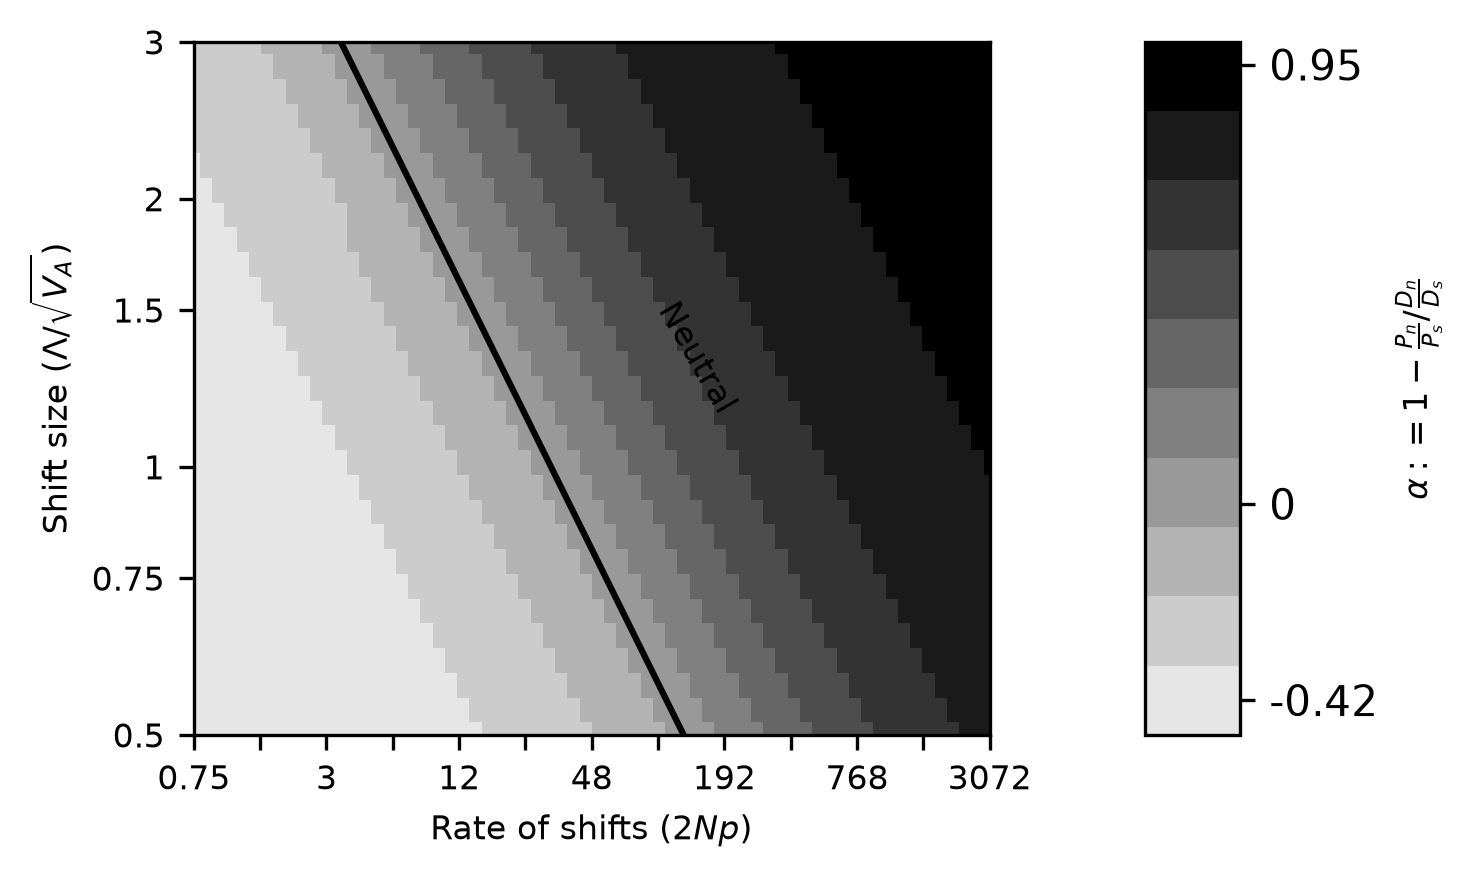

In [14]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

maf_threshold = 0.1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-0.5, 1.05, 0.15)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()